In [57]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, timedelta
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

plots_filepath = 'plots/august-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

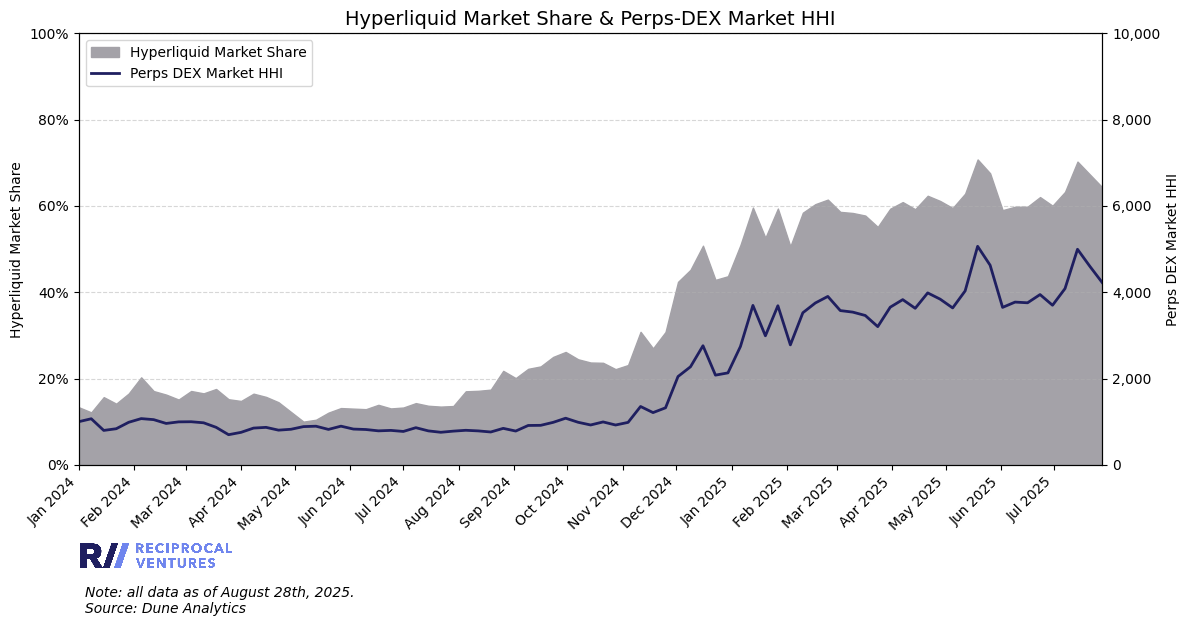

In [58]:
def plot_perpetual_volumes_from_json(json_path):
    # Load & parse the weekly JSON
    with open(json_path, 'r') as f:
        js = json.load(f)
    rows = js['result']['rows']
    df_w = pd.DataFrame(rows)
    # parse week → datetime
    df_w['date'] = pd.to_datetime(df_w['week'], utc=True)
    
    # Pivot so each row is a week, each column a product
    weekly = (
        df_w
        .pivot_table(
            index='date',
            columns='product_name',
            values='volume',
            aggfunc='sum'
        )
        .fillna(0)
    )
    
    # Compute total weekly volume & drop any weeks with zero total
    weekly['total_volume'] = weekly.sum(axis=1)
    weekly = weekly[weekly['total_volume'] > 0]

    # Market share (Hyperliquid) & HHI
    weekly['market_share'] = weekly['Hyperliquid Perps'] / weekly['total_volume'] * 100
    shares = weekly.drop(columns=['total_volume','market_share']).div(weekly['total_volume'], axis=0) * 100
    weekly['hhi'] = (shares ** 2).sum(axis=1)
    plot_df = weekly

    # Filter by index
    plot_df = plot_df[plot_df.index >= pd.to_datetime('2024-01-01', utc=True)]

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Area: Hyperliquid 7-week avg share
    ax1.fill_between(
        plot_df.index, plot_df['market_share'],
        color="#a4a2a8", alpha=1,
        label="Hyperliquid Market Share"
    )
    ax1.set_ylabel("Hyperliquid Market Share")
    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_formatter(PercentFormatter())

    # X-axis from first → last
    ax1.set_xlim(plot_df.index[0], plot_df.index[-1])
    ax1.margins(x=0)
    fig.subplots_adjust(left=0.07)

    # Monthly tick locator & formatter
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Line: Perps-DEX HHI
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df.index, plot_df['hhi'],
        color="#1f1f60", linewidth=2,
        label="Perps DEX Market HHI"
    )
    ax2.set_ylabel("Perps DEX Market HHI")
    ax2.set_ylim(0, 10_000)
    ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    # Title, grid & legend
    ax1.set_title(
        "Hyperliquid Market Share & Perps-DEX Market HHI",
        fontsize=14
    )
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    # Add logo & footer text
    add_logo(ax1, position=(0.075, -0.21))
    latest = plot_df.index[-1].strftime("%b %d, %Y")
    plt.figtext(
        0.075, -0.03,
        f"Note: all data as of {date}.\nSource: Dune Analytics",
        ha="left", fontsize=10, style="italic"
    )

    # tighten & save
    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(
        f"{plots_filepath}/hyperliquid_marketshare_hhi_7w.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# Usage
plot_perpetual_volumes_from_json("raw-data/dune-raw-data/dune_weekly-perps-dex-volumes.json")


In [59]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{metric}_data/{asset_slug}_{metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{metric}"] = rev_df[f"{asset_slug}-{metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{metric}"]]

        # Load TVL data
        tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
        with open(tvl_path) as tvl_f:
            tvl_data = json.load(tvl_f)

        tvl_df = pd.DataFrame(
            tvl_data['tvl'],
            columns=['date', 'totalLiquidityUSD']
        )
        tvl_df.rename(columns={
            'date': 'timestamp',
            'totalLiquidityUSD': f'{asset_slug}-tvl'
        }, inplace=True)
        tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
        tvl_df = tvl_df[['date', f'{asset_slug}-tvl']]
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, tvl_df, on="date", how="outer")

        # Fill blanks
        interim_df = interim_df.ffill()
        
        # Calculate multiple
        interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple'] = interim_df[f'{asset_slug}-annualized-{metric}'] / interim_df[f'{asset_slug}-tvl']
        interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple-7d'] = interim_df[f'{asset_slug}-annualized-{metric}-to-tvl-multiple'].rolling(window=7, min_periods=1).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    fdv_cols = [
        f"{asset_slug}-tvl"
        for asset_slug, asset_name in assets.items()
    ]
    mult_cols = [
        f'{asset_slug}-annualized-{metric}-to-tvl-multiple'
        for asset_slug, asset_name in assets.items()
    ]  
        
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master['tvl_weighted_avg_multiple'] = sum(weighted_terms)

    df_master['tvl_weighted_avg_multiple-7d'] = df_master['tvl_weighted_avg_multiple'].rolling(window=7, min_periods=1).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-annualized-{metric}-to-tvl-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: Return on Assets')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.3, f"Note: all data as of {date}.\nROA calcualted as annualized fees / TVL. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}select-{category_title}-roas.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'tvl_weighted_avg_multiple'].median(), 2) * 100
    latest_cohort_multiple = round(df_master[f'tvl_weighted_avg_multiple'].dropna().iloc[-1],2) * 100
    mean_cohort = round(df_master[f'tvl_weighted_avg_multiple'].mean(), 2) * 100
    percentile_80_cohort = round(df_master[f'tvl_weighted_avg_multiple'].quantile(0.80),2) * 100
    percentile_20_cohort = round(df_master[f'tvl_weighted_avg_multiple'].quantile(0.20),2) * 100
    stdev_cohort = round(df_master[f'tvl_weighted_avg_multiple'].std(),2) * 100

    stats_cohort = {
        "median_multiple": median_cohort,
        'latest_multiple': latest_cohort_multiple,
        'mean_multiple': mean_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'stdev_multiple': stdev_cohort
    }

    # Print results in human-readable format
    print()
    print(f"{category_title} ROA Statistics:")
    print(f"Median ROA: {median_cohort:,.0f}%")
    print(f"Latest ROA: {latest_cohort_multiple:,.0f}%")
    print(f"Mean ROA: {mean_cohort:,.0f}%")
    print(f"80th Percentile ROA: {percentile_80_cohort:,.0f}%")
    print(f"20th Percentile ROA: {percentile_20_cohort:,.0f}%")
    print(f'Standard Deviation: {stdev_cohort:,.0f}%')
    print()

    return stats_cohort

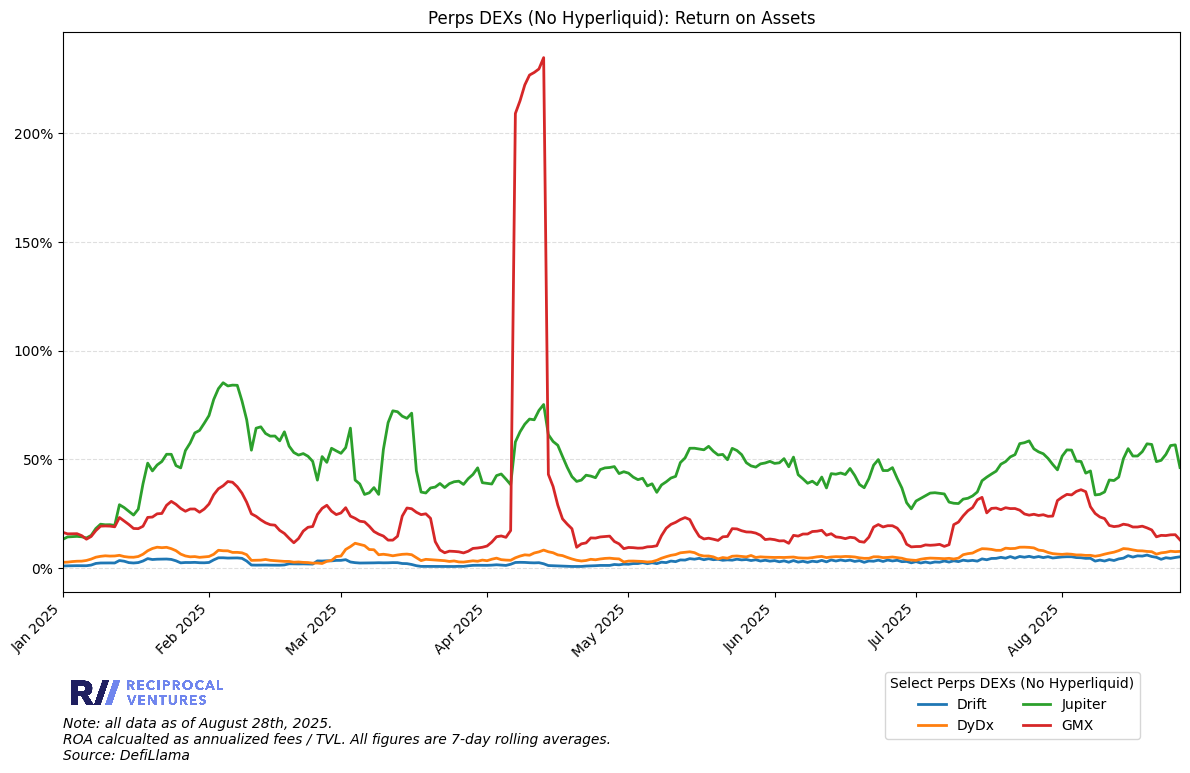


Perps DEXs (No Hyperliquid) ROA Statistics:
Median ROA: 28%
Latest ROA: 3%
Mean ROA: 31%
80th Percentile ROA: 38%
20th Percentile ROA: 18%
Standard Deviation: 22%



In [60]:
# Call the function
perps_dexs = {
          'drift': 'Drift',
          'dydx': 'DyDx',
          'jupiter': 'Jupiter',
          'gmx': 'GMX'
             }

# 'metric' should be 'Fees' or 'Revenue'
start_date = '2025-01-01'
assets = perps_dexs
metric = 'Fees'
category_title = 'Perps DEXs (No Hyperliquid)'

perps_dexs_no_hyperliquid_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

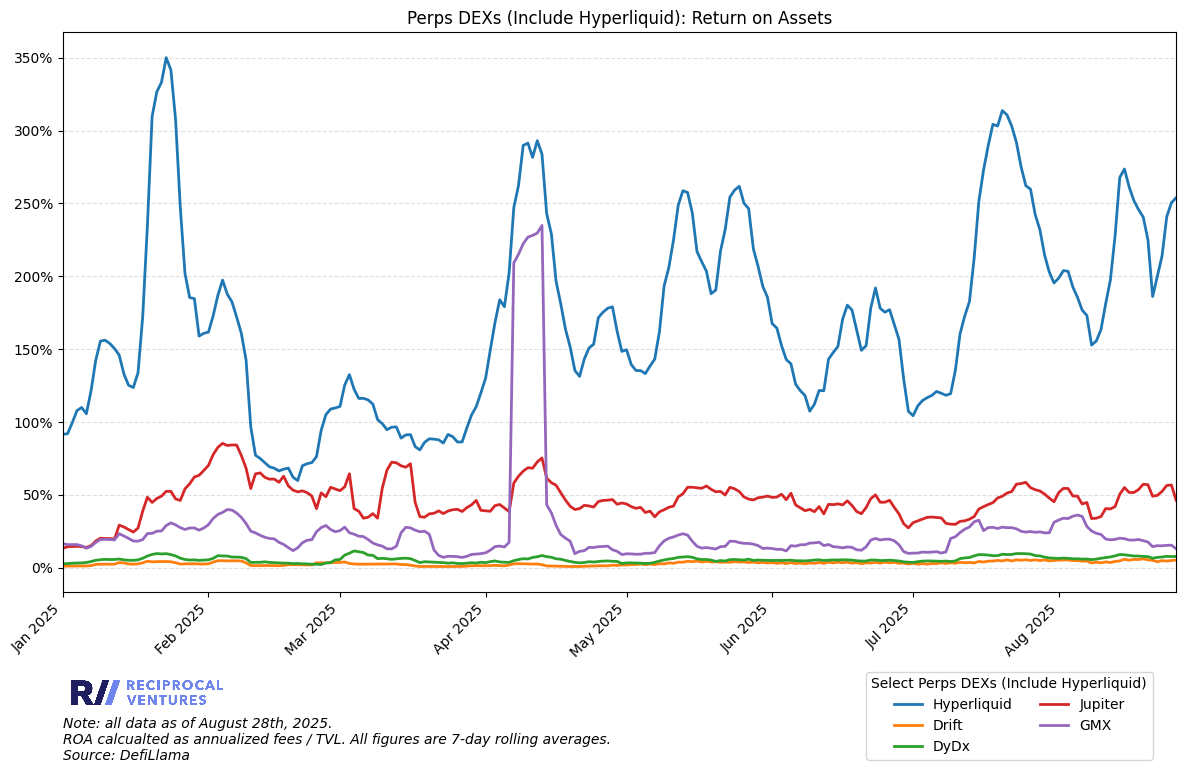


Perps DEXs (Include Hyperliquid) ROA Statistics:
Median ROA: 41%
Latest ROA: 35%
Mean ROA: 44%
80th Percentile ROA: 59%
20th Percentile ROA: 28%
Standard Deviation: 25%



In [61]:
# Call the function
perps_dexs = {'hyperliquid': 'Hyperliquid',
          'drift': 'Drift',
          'dydx': 'DyDx',
          'jupiter': 'Jupiter',
          'gmx': 'GMX'
             }

# 'metric' should be 'Fees' or 'Revenue'
start_date = '2025-01-01'
assets = perps_dexs
metric = 'Fees'
category_title = 'Perps DEXs (Include Hyperliquid)'

perps_dexs_incl_hyperliquid_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

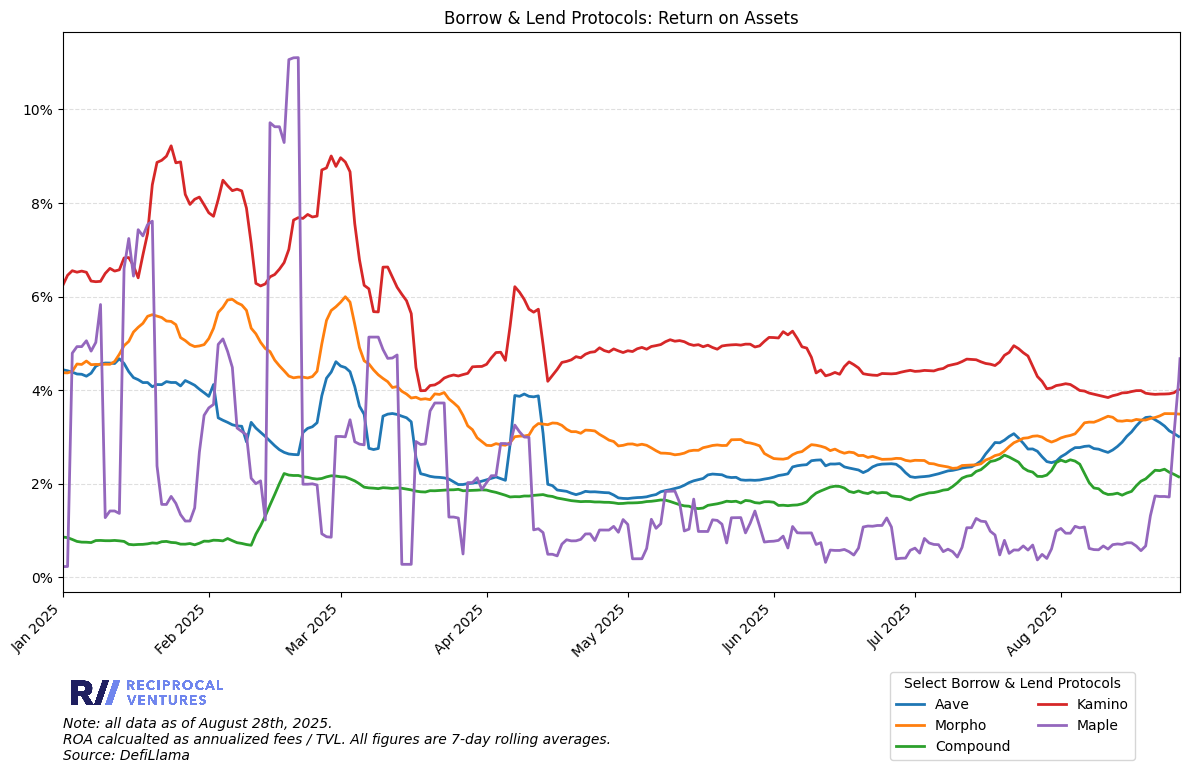


Borrow & Lend Protocols ROA Statistics:
Median ROA: 3%
Latest ROA: 3%
Mean ROA: 3%
80th Percentile ROA: 4%
20th Percentile ROA: 2%
Standard Deviation: 1%



In [62]:
# Call the function
borrow_lend_protocols = {'aave': 'Aave',
                         'morpho': 'Morpho',
                         'compound': 'Compound',
                         'kamino': 'Kamino',
                         'maple-finance': 'Maple',
                        }

# 'metric' should be 'Fees' or 'Revenue'
assets = borrow_lend_protocols
category_title = 'Borrow & Lend Protocols'

borrow_lend_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

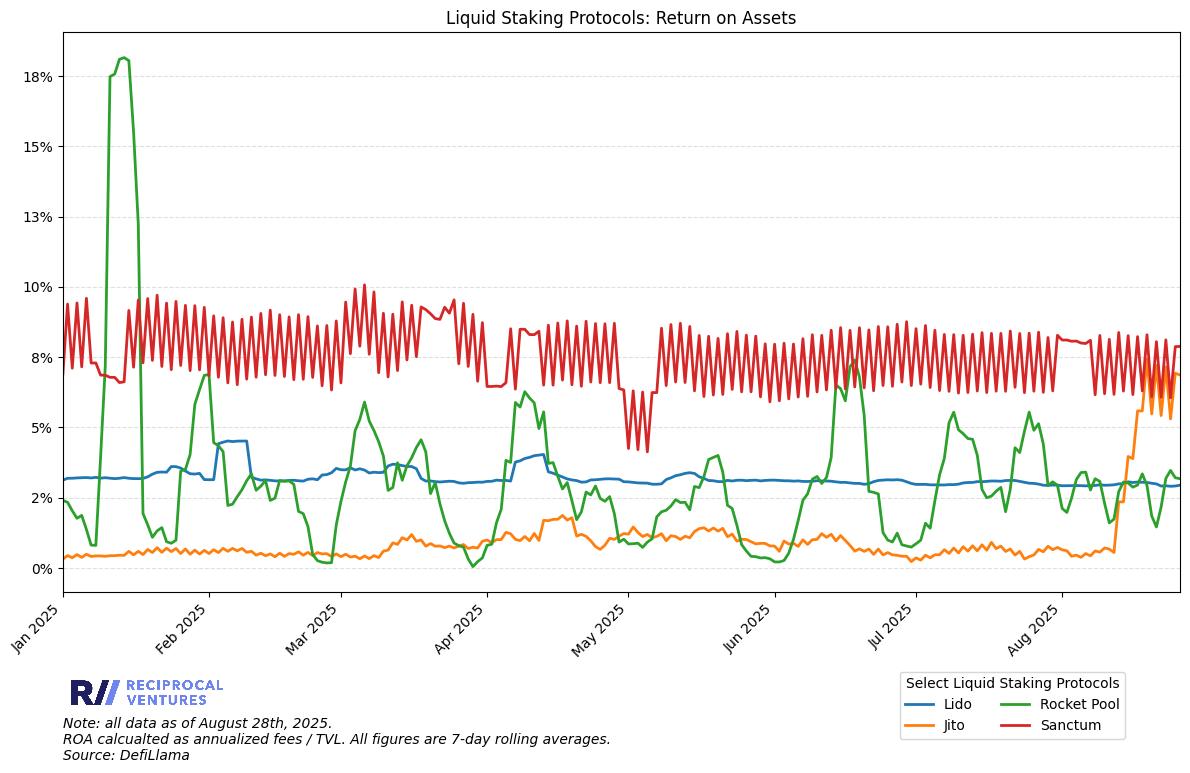


Liquid Staking Protocols ROA Statistics:
Median ROA: 3%
Latest ROA: 4%
Mean ROA: 3%
80th Percentile ROA: 4%
20th Percentile ROA: 3%
Standard Deviation: 1%



In [63]:
# Call the function
liquid_staking = {'lido': 'Lido',
                        'jito-liquid-staking': 'Jito',
                        'rocket-pool': 'Rocket Pool',
                        'sanctum-validator-lsts': 'Sanctum'
                       }

# 'metric' should be 'Fees' or 'Revenue'
assets = liquid_staking
category_title = 'Liquid Staking Protocols'

liquid_staking_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

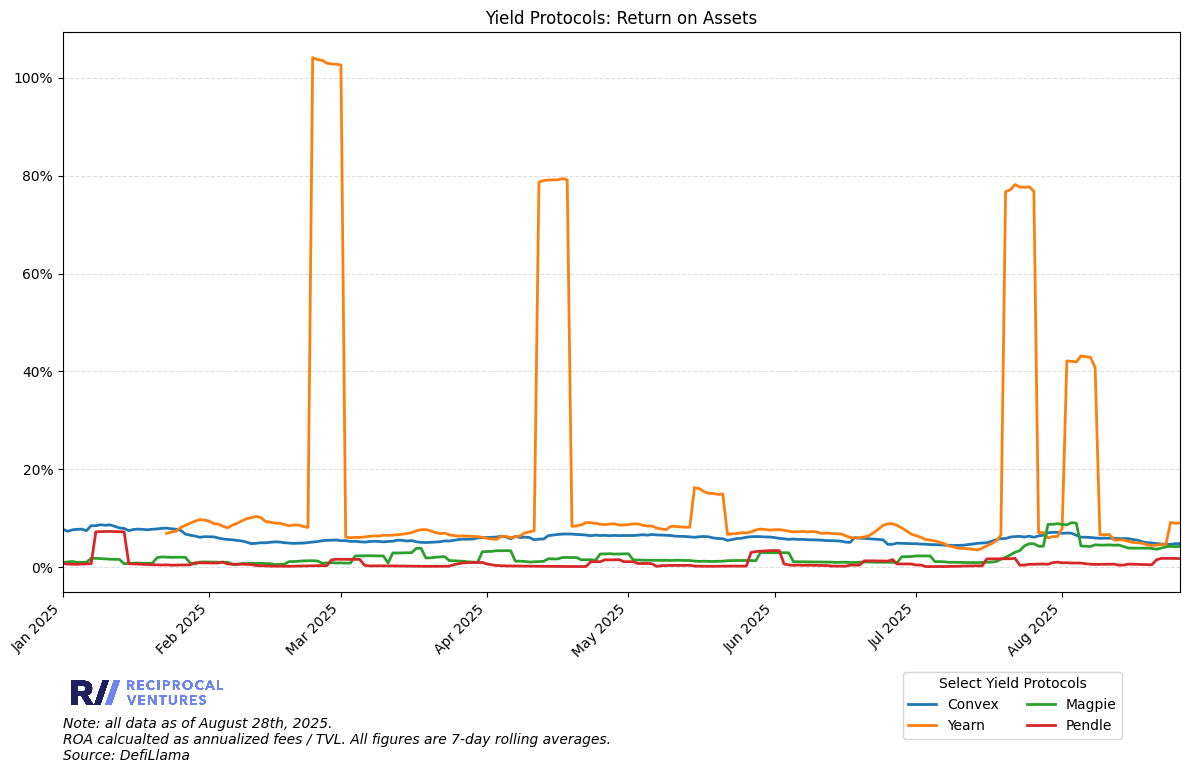


Yield Protocols ROA Statistics:
Median ROA: 2%
Latest ROA: 1%
Mean ROA: 2%
80th Percentile ROA: 2%
20th Percentile ROA: 1%
Standard Deviation: 3%



In [64]:
# Call the function
yield_protocols= {'convex-finance': 'Convex',
          'yearn-finance': 'Yearn',
          'magpie-ecosystem': 'Magpie',
          'pendle': 'Pendle'
             }

# 'metric' should be 'Fees' or 'Revenue'
assets = yield_protocols
category_title = 'Yield Protocols'

yield_stats = annualized_fees_vs_TVL_asset(start_date, assets, metric, category_title)

In [65]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    'Perps DEXs (Incl. Hyperliquid)':                perps_dexs_incl_hyperliquid_stats,
    'Perps DEXs (No Hyperliquid)': perps_dexs_no_hyperliquid_stats,
    'Borrow / Lend': borrow_lend_stats,
    'Liquid Staking': liquid_staking_stats,
    'Yield Aggregator': yield_stats

})

combined_stats.index = [
    'Median',
    'Most Recent',
    'Mean',
    '80th Percentile',
    '20th Percentile',
    'Standard Deviation'
]

# Re-order and keep only the fields I want to display
desired_order = ['Median', '80th Percentile', '20th Percentile', 'Standard Deviation']
filtered_stats = combined_stats.reindex(desired_order)

styled = (
    filtered_stats
      .style
      .set_caption("Annualized Fees / TVL by Protocol Type")
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("font-weight", "bold"),
             ("caption-side", "top"),
             ("text-decoration", "underline")
           ]},
          {"selector": "thead th", "props": [("font-weight", "normal")]},
          {"selector": "tbody th", "props": [("font-weight", "normal")]}
      ], overwrite=False)
      .format(lambda v: f"{v:,.0f}%" if pd.notnull(v) else "")
)

display(styled)


print(f"""
Notes:
 • All data from {start_date} to {date}.
 • Perp DEXs includes: Drift, dYdX, GMX, Hyperliquid, and Jupiter.
 • Borrow / Lend Protocols includes: Aave, Compound, Kamino, Maple, and Morpho.
 • Liquid Staking Protocols includes: Lido, Jito, Rocket Pool, and Sanctum.
 • Yield Aggregator Protocols includes: Convex, Magpie, Pendle, and Yearn.
 • All figures are TVL-weighted.
 
 Sources: DefiLlama.
""")

,Perps DEXs (Incl. Hyperliquid),Perps DEXs (No Hyperliquid),Borrow / Lend,Liquid Staking,Yield Aggregator
Median,41%,28%,3%,3%,2%
80th Percentile,59%,38%,4%,4%,2%
20th Percentile,28%,18%,2%,3%,1%
Standard Deviation,25%,22%,1%,1%,3%



Notes:
 • All data from January 1st, 2025 to August 28th, 2025.
 • Perp DEXs includes: Drift, dYdX, GMX, Hyperliquid, and Jupiter.
 • Borrow / Lend Protocols includes: Aave, Compound, Kamino, Maple, and Morpho.
 • Liquid Staking Protocols includes: Lido, Jito, Rocket Pool, and Sanctum.
 • Yield Aggregator Protocols includes: Convex, Magpie, Pendle, and Yearn.
 • All figures are TVL-weighted.
 
 Sources: DefiLlama.



In [66]:
def plot_tvl_single_asset(asset_slug, asset_name, start_date):
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    # Load TVL data
    tvl_path = f"raw-data/defillama-raw-data/tvl_data/{asset_slug}_tvl.json"
    with open(tvl_path) as tvl_f:
        tvl_data = json.load(tvl_f)

    tvl_df = pd.DataFrame(
        tvl_data['tvl'],
        columns=['date', 'totalLiquidityUSD']
    )
    tvl_df.rename(columns={
        'date': 'timestamp',
        'totalLiquidityUSD': f'{asset_slug}-tvl'
    }, inplace=True)
    tvl_df['date'] = pd.to_datetime(tvl_df['timestamp'], unit='s')
    tvl_df = tvl_df[['date', f'{asset_slug}-tvl']]

    tvl_df = tvl_df.ffill()

    # Calculate trailing 7-day average
    tvl_df[f"{asset_slug}-tvl-7d"] = tvl_df[f"{asset_slug}-tvl"].rolling(window=7, min_periods=1).mean()

    df_master = tvl_df

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    ax.stackplot(
        df_master['date'], 
        df_master[f'{asset_slug}-tvl-7d'], 
        labels=asset_name, 
        colors = asset_colors
    )
    
    # Setting labels and title
    ax.set_title(f'{asset_name} TVL')
    ax.margins(x=0)
    delta = (today - df_master['date'].iloc[0]).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}{asset_slug}-tvl.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

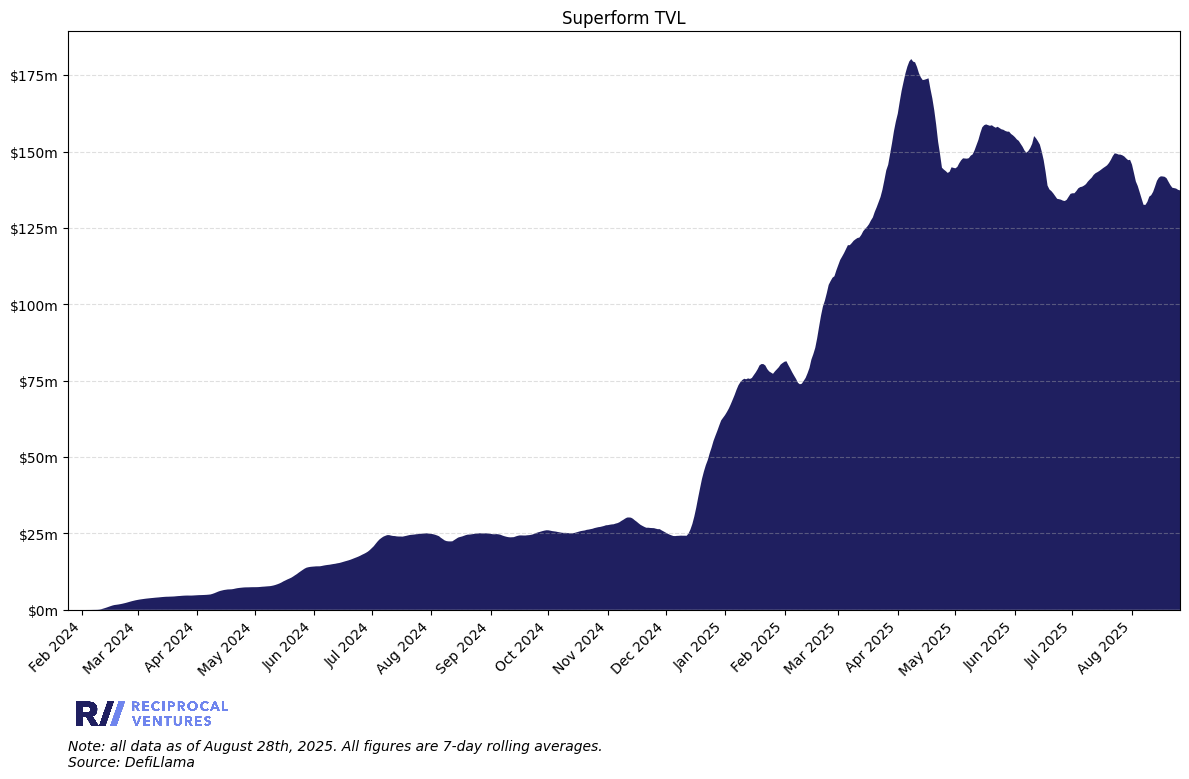

In [67]:
asset_slug = 'superform' 
asset_name = 'Superform'
start_date = '2024-01-01'

plot_tvl_single_asset(asset_slug, asset_name, start_date)

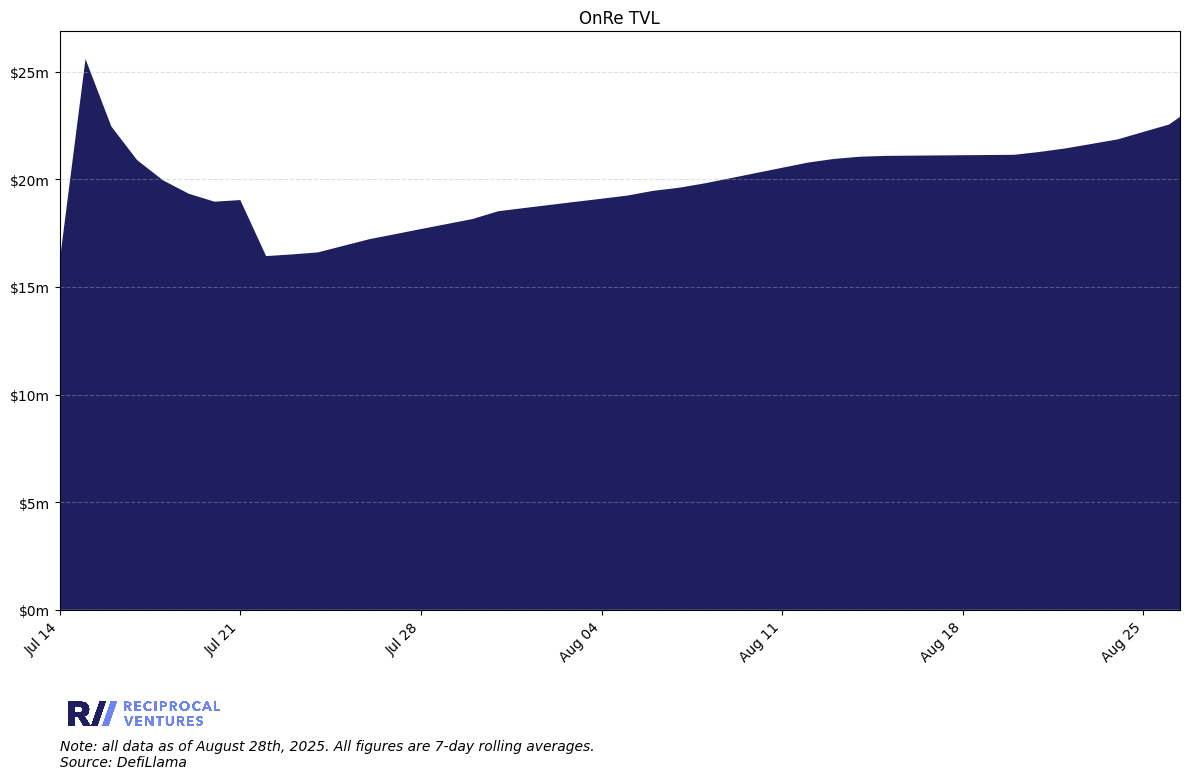

In [68]:
asset_slug = 'onre' 
asset_name = 'OnRe'
start_date = '2025-06-01'

plot_tvl_single_asset(asset_slug, asset_name, start_date)

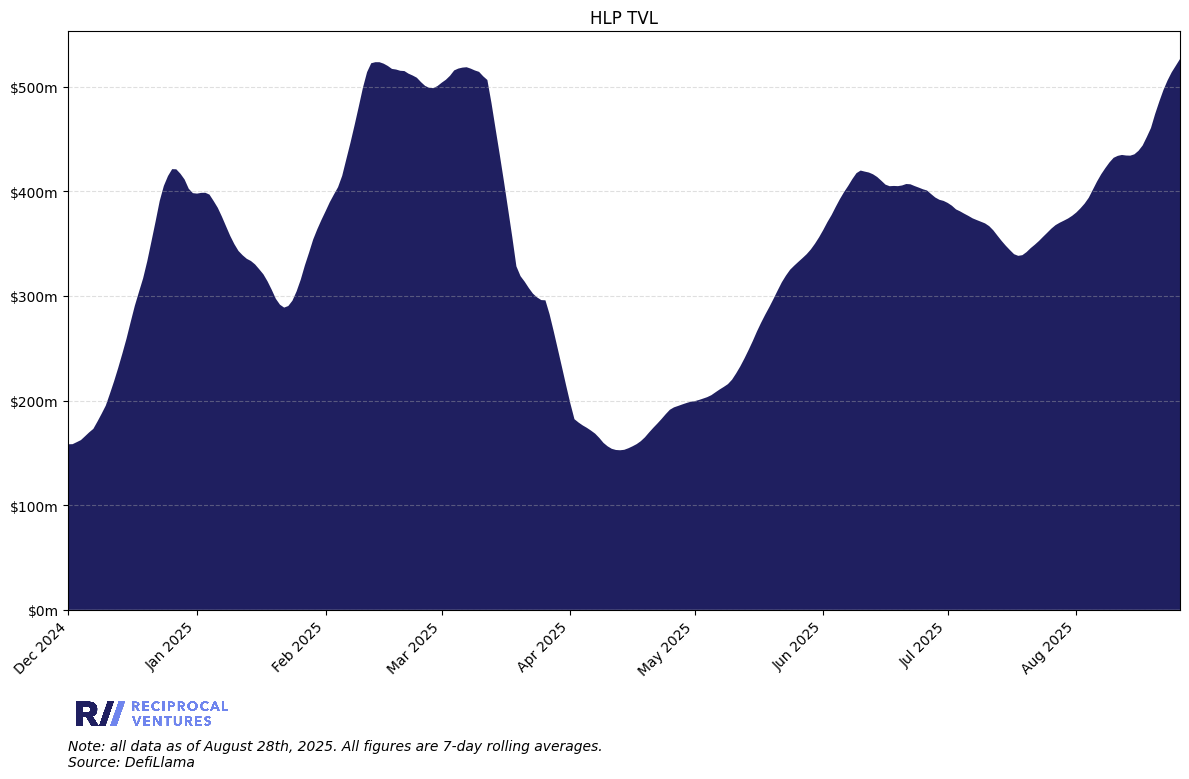

In [69]:
asset_slug = 'hyperliquid-hlp' 
asset_name = 'HLP'
start_date = '2024-01-01'

plot_tvl_single_asset(asset_slug, asset_name, start_date)

In [70]:
asset_colors = ['#1f1f60',
                '#313EA5',
                '#7C9ACC',
                '#ADD8E6',
                '#333333',
                '#494949',
                '#5F5F5F',
                '#757575',
                '#8A8A8A',
                '#A0A0A0',
                '#B6B6B6',
                '#CCCCCC'
               ]

def hyperliquid_daily_voume_by_asset(start_date, n_assets, n_col):
    dfs = []
    # Convert daily volume json to dataframe
    path = f'raw-data/dune-raw-data/dune_hyperliquid-daily-volume-by-coin.json'
    with open(path, 'r') as f:
        data = json.load(f)
    entries = data['result']['rows']
    
    # Set up dataframe
    df = pd.DataFrame.from_records(entries)
    df['date'] = pd.to_datetime(df['day'], format='%Y-%m-%d %H:%M:%S.%f UTC').dt.normalize()
    df_wide = df.pivot(index='date', columns='coin', values='daily_volume_usd').fillna(0).sort_index()

    # Slice the date window
    start     = pd.Timestamp(start_date)
    end_date  = (datetime.now() - timedelta(days=0)).date()
    df_plot   = df_wide.loc[start:end_date]
    if df_plot.empty:
        print(f"No data found between {start.date()} and {end_date}.")
        return

    # Pick n assets and roll up the rest
    totals       = df_plot.sum(axis=0)
    top_assets   = totals.nlargest(n_assets).index.tolist()
    other_assets = [c for c in df_plot.columns if c not in top_assets]

    df_top = df_plot[top_assets].copy()
    df_top['Other'] = df_plot[other_assets].sum(axis=1)

    # Replace w/ 7-day rolling averages
    df_top = df_top.rolling(window=7, min_periods=1).mean()

    # determine stacking order:
    #    - take top_assets sorted by descending total (so largest is first → bottom)
    #    - then put 'Other' last → top
    ordered = totals[top_assets].sort_values(ascending=False).index.tolist()
    stack_cols = ordered + ['Other']

    # pick a grey for “Other”
    grey = '#CCCCCC'

    # build the colors list: use the existing palette for the top-N,
    # then force “Other” to grey
    colors = asset_colors[:len(stack_cols)-1] + [grey]

    # normalize to 100% per day
    df_pct = df_top.div(df_top.sum(axis=1), axis=0)

    # now plot
    fig, ax = plt.subplots(figsize=(12,6))
    df_pct.plot.area(
        stacked=True,
        ax=ax,
        color=asset_colors[:len(df_pct.columns)-1] + ['#CCCCCC'],
        alpha=0.8
    )

    ax.set_xlabel('')

     # y-axis as %
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(0,1)

    delta = (end_date - start.date()).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
   
    ax.tick_params(axis='x', rotation=45)
    ax.minorticks_off()
    
    ax.margins(x=0)
    ax.legend(loc='lower right', ncol=n_col, bbox_to_anchor=(1,-0.28))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    last_date = df_top.index.max().date()
    add_logo(ax, position=(0.075, -0.2))
    
    plt.figtext(
        0.12, -0.15,
        f"Note: all data as of {date}. All figures are 7-day rolling averages.\n{len(other_assets)} assets included in 'Other'.\nSource: Dune Analytics",
        ha='left', fontsize=10, style='italic'
    )
    ax.set_title('Hyperliquid Daily Volume by Asset')

    os.makedirs('plots', exist_ok=True)
    plt.savefig(
        f'{plots_filepath}hyperliquid-daily-volume-by-asset-100%.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    print(df_pct.tail())


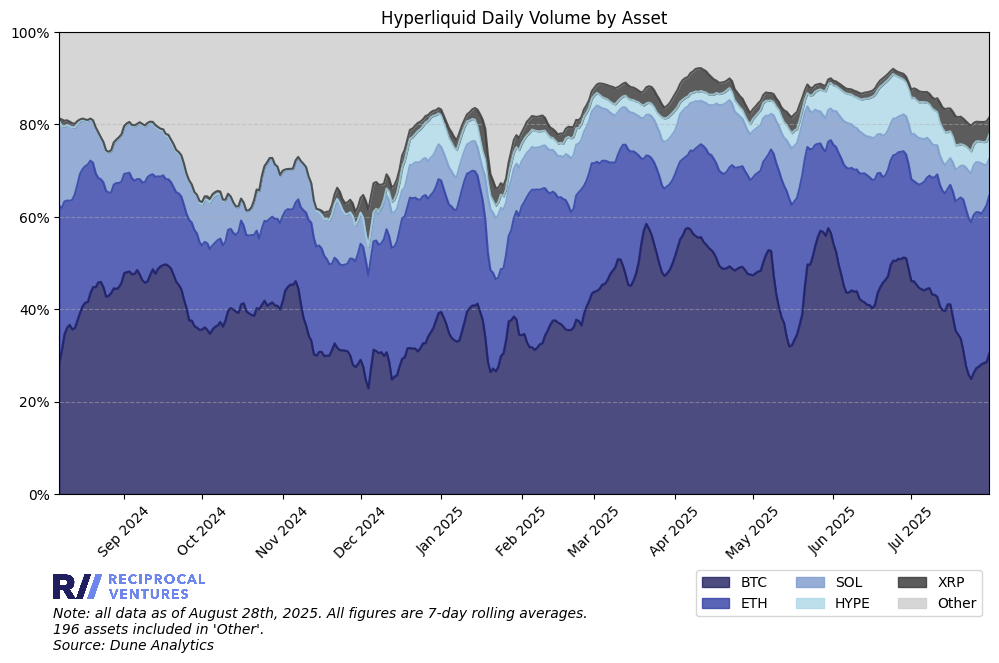

coin             BTC       ETH       SOL      HYPE       XRP     Other
date                                                                  
2025-07-27  0.275863  0.333853  0.108145  0.045473  0.042060  0.194606
2025-07-28  0.281042  0.325476  0.109132  0.046809  0.042781  0.194760
2025-07-29  0.283603  0.331839  0.097012  0.049242  0.043494  0.194809
2025-07-30  0.286253  0.339142  0.086817  0.051131  0.043350  0.193308
2025-07-31  0.304164  0.341521  0.079615  0.052813  0.036752  0.185134


In [71]:
start_date = '2024-08-01'
n_assets = 5
n_col = 3

hyperliquid_daily_voume_by_asset(start_date, n_assets, n_col)

In [72]:
# Function plot fees or revenue for any projects as a timeseries
def fees_or_revenue_timeseries(metric, assets, start_date, end_date):
    
    asset_colors = ['#1f1f60',
                    '#4A5DB2',
                    '#494949',
                    '#A0A0A0'
                   ]
    
    metric_identifier = 'Revenue'
    if metric == 'dailyFees':
        metric_identifier = 'Fees'
    
    df_master = None

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)
    
    for asset_slug, asset_name in assets.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{asset_slug}_{metric_identifier}.json') as f:
            data = json.load(f)
        
        # Select only the two real keys, then rename
        raw_df = pd.DataFrame(
            data['totalDataChart'],
            columns=['date', asset_name]
        )
        raw_df.rename(columns={
            'date': 'timestamp',
            f'{metric}': asset_name
        }, inplace=True)
        raw_df['date'] = pd.to_datetime(raw_df['timestamp'], unit='s')
        raw_df = raw_df[['date', asset_name]]
        raw_df[asset_name] = raw_df[asset_name].rolling(window=7).mean()
    
        # Merge dataframes
        df_master = raw_df if df_master is None else df_master.merge(raw_df, on='date', how='outer')
        df_master.fillna(0).infer_objects(copy=False)

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
    
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')
    
    # Grab the last row of numbers
    last_row = df_master.iloc[-1]

    # Grab asset names
    assets = df_master.columns[1:].tolist()

    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[asset] for asset in assets]
    colors = asset_colors[:len(assets)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=assets,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}m'))
    delta = (end_date - pd.to_datetime(start_date)).days
    if delta <500:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    elif delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax.xaxis.set_major_locator(MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45)
    ax.margins(x=0)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.17))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    if metric == 'dailyFees':
        ax.set_title(f'Daily Fees by Protocol')
    if metric == 'dailyRevenue':
        ax.set_title(f'Daily Revenue by Protocol')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/breakout-{metric}-timeseries.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

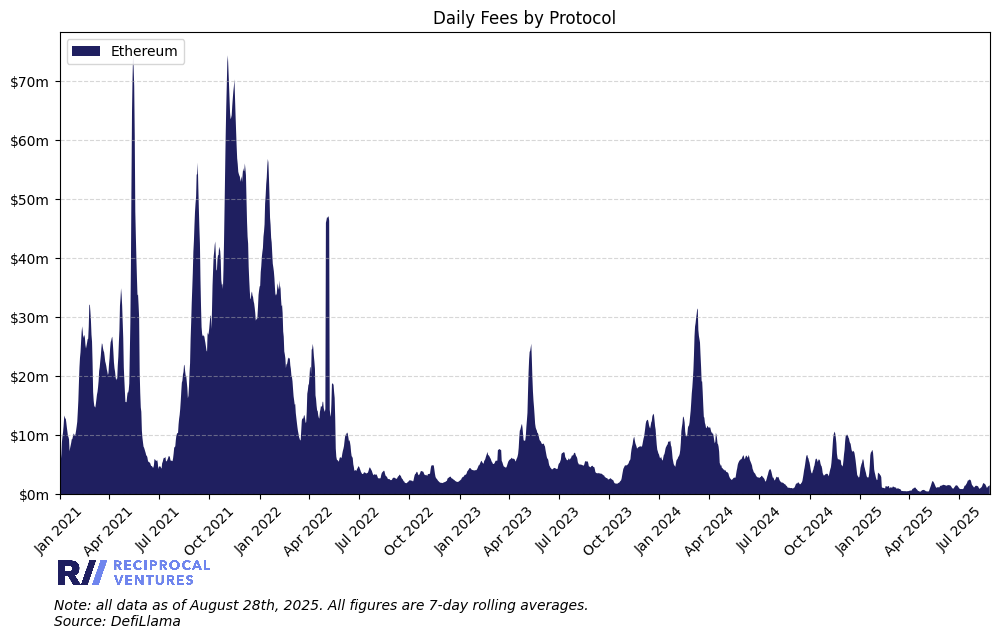

           date      Ethereum
3675 2025-08-22  1.190945e+06
3676 2025-08-23  1.271592e+06
3677 2025-08-24  1.355716e+06
3678 2025-08-25  1.414084e+06
3679 2025-08-26  1.489166e+06


In [73]:
# Call the function
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
start_date = '2021-01-01'
end_date = today
assets = {'ethereum': 'Ethereum'}

fees_or_revenue_timeseries(metric, assets, start_date, end_date)

In [74]:
def annualized_revenue_vs_price_to_annualized_metric(metric, asset_slug, asset_name, start_date, date):
    # Load revenue data
    with open(f'raw-data/defillama-raw-data/{metric[0]}_data/{asset_slug}_{metric[1]}.json', "r") as f:
        metric_data = json.load(f)
    
    metric_df = pd.DataFrame(metric_data["totalDataChart"], columns=["timestamp", f"{metric[1]}"])
    metric_df["date"] = pd.to_datetime(metric_df["timestamp"], unit="s")
    metric_df = metric_df[["date", f"{metric[1]}"]]
    
    # Annualize revenue and calculate trailing 7-day average
    metric_df[f'annualized-{metric[1]}'] = metric_df[f"{metric[1]}"] * 365
    metric_df[f"annualized-{metric[1]}-7d"] = metric_df[f"annualized-{metric[1]}"].rolling(window=7, min_periods=1).mean()

    # Load mcap data
    with open(f"raw-data/messari-raw-data/asset-data/{asset_id}_marketcap.json", 'r') as f:
        mcap_data = json.load(f)
    
    points = mcap_data['data']['points']
    mcap_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])
    mcap_df["date"] = pd.to_datetime(mcap_df["timestamp"], unit="s")
    mcap_df = mcap_df[['date','fully-diluted-marketcap']]
    mcap_df['FDV-7d'] = mcap_df['fully-diluted-marketcap'].rolling(window=7).mean()
    
    # Merge datasets
    df = pd.merge(metric_df, mcap_df, on="date", how="inner")
    
    # Calculate P/S ratio and trailing 7-day average
    df[f'FDV-to-annualized-{metric[1]}-multiple'] = df['fully-diluted-marketcap'] / df[f'annualized-{metric[1]}']
    df[f'FDV-to-annualized-{metric[1]}-multiple-7d'] = df[f'FDV-to-annualized-{metric[1]}-multiple'].rolling(window=7, min_periods=1).mean()

    # Filter the data for a given time period
    plot_df = df[df['date'] >= start_date]
    
    # 6) Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Area: Hyperliquid market share
    ax1.fill_between(
        plot_df["date"], plot_df[f"annualized-{metric[1]}-7d"],
        color="#a4a2a8", alpha=1,
        label=f"Annualized {metric[1]}"
    )
    ax1.set_ylabel(f"Annualized {metric[1]}")
    ax1.set_ylim(bottom=0)
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}b'))
    
    # Monthly ticks, lighter crowding
    delta = (end_date - pd.to_datetime(start_date)).days
    if delta <500:
        ax1.xaxis.set_major_locator(MonthLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    elif delta < 60:
        ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax1.xaxis.set_major_locator(MonthLocator(bymonth=[1, 4, 7, 10], bymonthday=1))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.xticks(rotation=45)
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
    
    # Line: FDV / annualzied revenue
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df["date"], plot_df[f"FDV-to-annualized-{metric[1]}-multiple-7d"],
        color="#1f1f60", linewidth=2,
        label=f"FDV / Annualized {metric[1]}"
    )
    ax2.set_ylabel(f"FDV / Annualized {metric[1]}")
    ax2.set_ylim(bottom=0)
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}x'))

    # no extra padding
    ax1.margins(x=0)
    
    # Title, grid & legend
    ax1.set_title(f"{asset_name}: Annualized {metric[1]} vs. FDV / Annualized {metric[1]}", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.065, -0.03, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/{asset_id}-annualized-{metric[1]}_vs_FDV-to-annualized-{metric[1]}_7d.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(10))

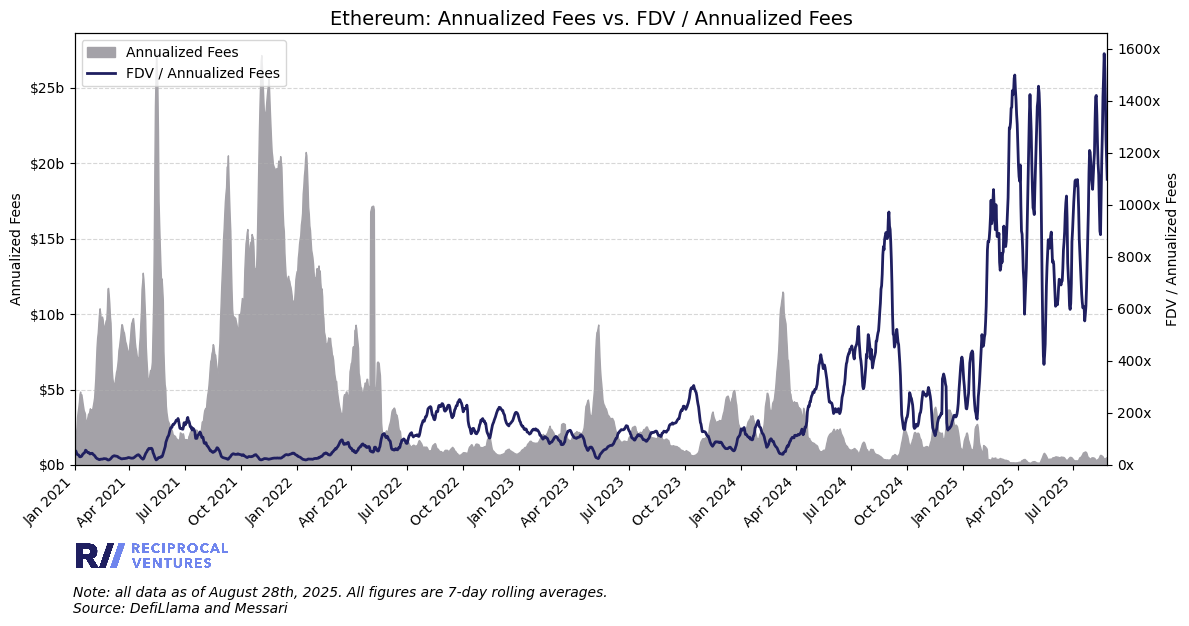

           date     Fees  annualized-Fees  annualized-Fees-7d  \
1689 2025-08-17   623984        227754160        6.222263e+08   
1690 2025-08-18   848006        309522190        5.930823e+08   
1691 2025-08-19   792710        289339150        5.202851e+08   
1692 2025-08-20  1309256        477878440        4.461478e+08   
1693 2025-08-21  1180143        430752195        3.645156e+08   
1694 2025-08-22  2878303       1050580595        4.346950e+08   
1695 2025-08-23  1268741        463090465        4.641310e+08   
1696 2025-08-24  1212856        442692440        4.948365e+08   
1697 2025-08-25  1256579        458651335        5.161407e+08   
1698 2025-08-26  1318284        481173660        5.435456e+08   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-Fees-multiple  \
1689             5.402402e+11  5.425188e+11                      2372.032144   
1690             5.210061e+11  5.440791e+11                      1683.259394   
1691             4.917757e+11  5.351708e+11 

In [75]:
metric = ('dailyFees', 'Fees')
assets = {'ethereum': 'Ethereum'}
start_date = '2021-01-01'

for asset_id, asset_name in assets.items():
    annualized_revenue_vs_price_to_annualized_metric(metric, asset_id, asset_name, start_date, date)

In [76]:
# Function for plotting revenue or fees / mcap or fdv charts for a set of assets

def revenue_vs_tvl_asset(start_date, assets, breakout_asset, bottom_metric, top_metric, category_title):
    df_master = None
    # Load revenue and FDV data
    for asset_slug, asset_name in assets.items():
        rev_path = f"raw-data/defillama-raw-data/daily{bottom_metric}_data/{asset_slug}_{bottom_metric}.json"
        with open(rev_path) as rev_f:
            rev_data = json.load(rev_f)
    
        rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", f"{asset_slug}-{bottom_metric}"])
        rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
        rev_df[f"{asset_slug}-annualized-{bottom_metric}"] = rev_df[f"{asset_slug}-{bottom_metric}"] * 365
        rev_df = rev_df[["date", f"{asset_slug}-annualized-{bottom_metric}"]]

        # Load fdv data
        fdv_path = f'raw-data/messari-raw-data/asset-data/{asset_slug}_marketcap.json'
        with open(fdv_path) as fdv_f:
            fdv_data = json.load(fdv_f)
        
        points = fdv_data['data']['points']
        fdv_df = pd.DataFrame(points, columns=[
            'timestamp',
            'circulating-marketcap',
            'circulating-marketcap-dominance',
            'fully-diluted-marketcap'
        ])
        fdv_df["date"] = pd.to_datetime(fdv_df["timestamp"], unit="s")
        if top_metric == 'FDV':
            fdv_df = fdv_df[['date','fully-diluted-marketcap']]
            fdv_df.rename(columns={'fully-diluted-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)

        if top_metric == 'MCAP':
            fdv_df = fdv_df[['date','circulating-marketcap']]
            fdv_df.rename(columns={'circulating-marketcap': f'{asset_slug}-{top_metric}'}, inplace=True)
        
        # Merge datasets for a given asset
        interim_df = pd.merge(rev_df, fdv_df, on="date", how="inner")
        
        # Calculate multiple
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'] = interim_df[f'{asset_slug}-{top_metric}'] / interim_df[f'{asset_slug}-annualized-{bottom_metric}']
        interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'] = interim_df[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple'].rolling(window=7).mean()
        
        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)
        df_master = df_master.ffill()

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # define which asset to exclude
    exclude = breakout_asset[0]
    
    # only include the others
    fdv_cols = [
        f"{slug}-{top_metric}"
        for slug in assets
        if slug != exclude
    ]
    mult_cols = [
        f"{slug}-{top_metric}-to-annualized-{bottom_metric}-multiple"
        for slug in assets
        if slug != exclude
    ]
    
    # per-row FDV denominator
    fdv_den = df_master[fdv_cols].sum(axis=1)
    
    # row-wise weights for each FDV column
    weights = df_master[fdv_cols].div(fdv_den, axis=0)
    
    # compute each asset’s weighted term
    weighted_terms = []
    for fdv_col, mult_col in zip(fdv_cols, mult_cols):
        term = weights[fdv_col] * df_master[mult_col]
        weighted_terms.append(term)
    
    # sum them to get your per-day FDV-weighted average
    df_master[f'{top_metric}_weighted_avg_multiple'] = sum(weighted_terms)

    df_master[f'{top_metric}_weighted_avg_multiple-7d'] = df_master[f'{top_metric}_weighted_avg_multiple'].rolling(window=7).mean()
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for asset_slug, asset_name in assets.items():
        ax.plot(
            df_master['date'], 
            df_master[f'{asset_slug}-{top_metric}-to-annualized-{bottom_metric}-multiple-7d'], 
            label=asset_name, 
            linewidth=2
        )
    
    # Setting labels and title
    ax.set_title(f'{category_title}: {top_metric} / Annualized {bottom_metric} (Log Scale)')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}x'))
    ax.set_ylim(1, 10000)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Center the legend below the chart
    plt.legend(title=f'Select {category_title}', bbox_to_anchor=(0.85, -0.13), loc='upper center', ncol=2)
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{category_title} multiples.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

    # Calculate statistical percentiles for multiple
    median_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].median(), 0)
    percentile_80_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.80),0)
    percentile_20_cohort = round(df_master[f'{top_metric}_weighted_avg_multiple'].quantile(0.20),0)
    latest_cohort_multiple = round(df_master[f'{top_metric}_weighted_avg_multiple'].dropna().iloc[-1],0)
    median_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].median(), 0)
    percentile_80_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.80),0)
    percentile_20_breakout = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].quantile(0.20),0)
    latest_breakout_multiple = round(df_master[f'{breakout_asset[0]}-{top_metric}-to-annualized-{bottom_metric}-multiple'].dropna().iloc[-1],0)

    stats_cohort = {
        "median_multiple": median_cohort,
        "80th_percentile_multiple": percentile_80_cohort,
        "20th_percentile_multiple": percentile_20_cohort,
        'latest_multiple': latest_cohort_multiple
    }

    stats_breakout = {
        "median_multiple": median_breakout,
        "80th_percentile_multiple": percentile_80_breakout,
        "20th_percentile_multiple": percentile_20_breakout,
        'latest_multiple': latest_breakout_multiple
    }
    
    # Print results in human-readable format
    print()
    print(f"{category_title} {top_metric} / Annualized {bottom_metric} Statistics (Excluding {breakout_asset[1]}):")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_cohort:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_cohort:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_cohort:,.0f}x")
    print(f"Latest Multiple: {latest_cohort_multiple:,.0f}x")
    print()
    print(f"{breakout_asset[1]} {top_metric} / Annualized {bottom_metric} Statistics:")
    print(f"Median {top_metric} / Annualized {bottom_metric}: {median_breakout:,.0f}x")
    print(f"80th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_80_breakout:,.0f}x")
    print(f"20th Percentile {top_metric} / Annualized {bottom_metric}: {percentile_20_breakout:,.0f}x")
    print(f"Latest Multiple: {latest_breakout_multiple:,.0f}x")
    print()

    return stats_cohort, stats_breakout

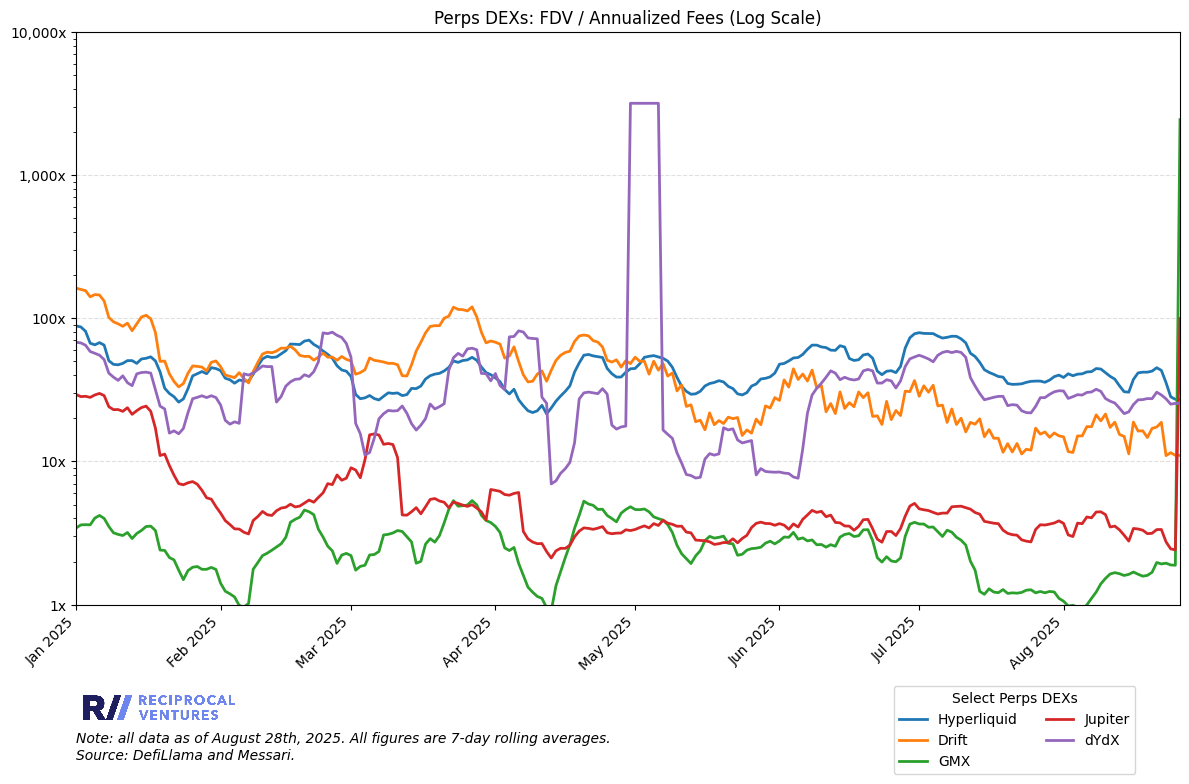


Perps DEXs FDV / Annualized Fees Statistics (Excluding Hyperliquid):
Median FDV / Annualized Fees: 9x
80th Percentile FDV / Annualized Fees: 16x
20th Percentile FDV / Annualized Fees: 6x
Latest Multiple: 1,096x

Hyperliquid FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 39x
80th Percentile FDV / Annualized Fees: 62x
20th Percentile FDV / Annualized Fees: 27x
Latest Multiple: 27x



In [77]:
# Call the function for perp dexs
perps_dexs = {'hyperliquid': 'Hyperliquid',
          'drift': 'Drift',
          'gmx': 'GMX',
          'jupiter': 'Jupiter',
              'dydx': 'dYdX'
         }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
start_date = '2025-01-01'
assets = perps_dexs
breakout_asset = ('hyperliquid', 'Hyperliquid')
bottom_metric = 'Fees'
top_metric = 'FDV'
category_title = 'Perps DEXs'

perps_stats, breakout_stats = revenue_vs_tvl_asset(
    start_date     = start_date,
    assets         = perps_dexs,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

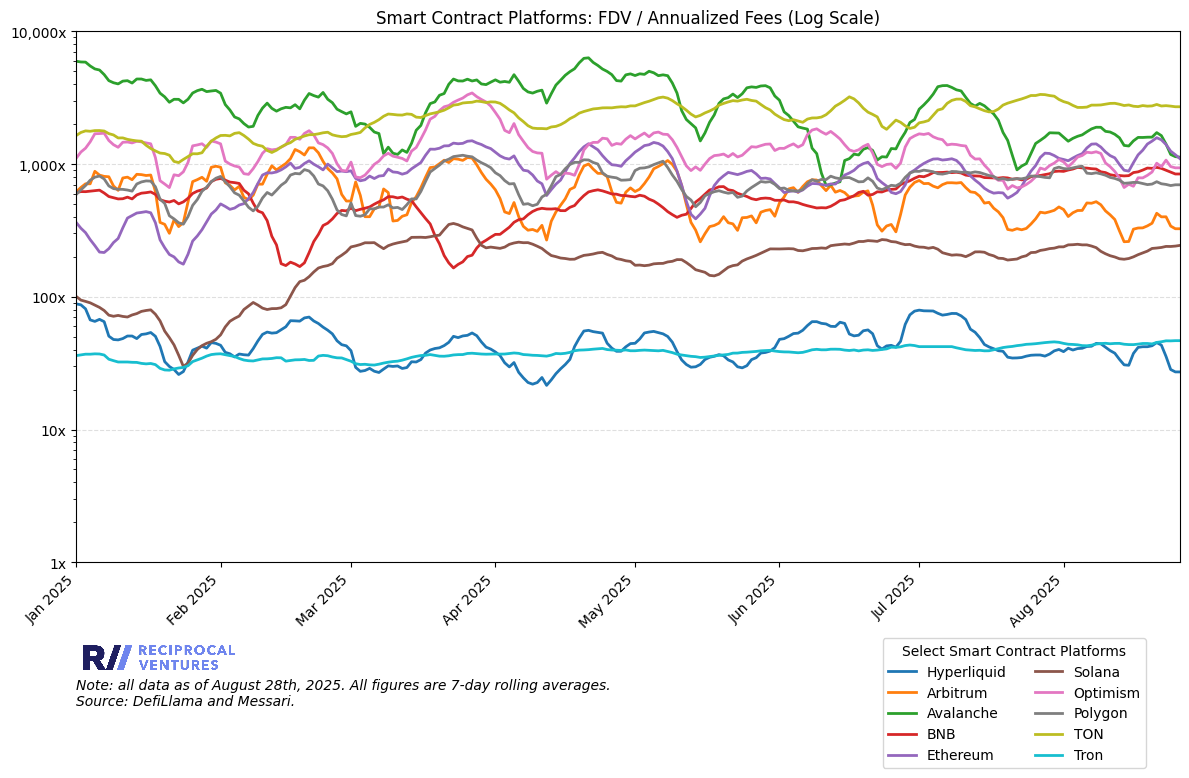


Smart Contract Platforms FDV / Annualized Fees Statistics (Excluding Hyperliquid):
Median FDV / Annualized Fees: 714x
80th Percentile FDV / Annualized Fees: 1,001x
20th Percentile FDV / Annualized Fees: 483x
Latest Multiple: 955x

Hyperliquid FDV / Annualized Fees Statistics:
Median FDV / Annualized Fees: 39x
80th Percentile FDV / Annualized Fees: 62x
20th Percentile FDV / Annualized Fees: 27x
Latest Multiple: 27x



In [78]:
# Call the function for smart contract platforms
smart_contract_platforms = {'hyperliquid': 'Hyperliquid',
          'arbitrum': 'Arbitrum',
          'avalanche': 'Avalanche',
          'bnb': 'BNB',
          'ethereum': 'Ethereum',
          'solana': 'Solana',
          'optimism': 'Optimism',
          'polygon': 'Polygon',
          'ton': 'TON',
          'tron': 'Tron'
             }

# 'bottom_metric' should be 'Fees' or 'Revenue'; 'top_metric' should be 'FDV' or 'MCAP'
assets = smart_contract_platforms
category_title = 'Smart Contract Platforms'


scp_stats, _ = revenue_vs_tvl_asset(
    start_date     = start_date,
    assets         = smart_contract_platforms,
    breakout_asset = breakout_asset,
    bottom_metric  = bottom_metric,
    top_metric     = top_metric,
    category_title = category_title
)

In [79]:
# Function for plotting tvl / mcap or fdv charts for a set of assets

def plot_mcap_to_annualized_metric_multiple(start_date, tickers, metric):
    
    df_master = None
    
    for ticker in tickers:
        # Load mcap / annualized metric multiple
        path = f"raw-data/yahoofinance-raw-data/{ticker}_mcap_to_annualized_{metric}.json"
        with open(path) as f:
            data = json.load(f)
    
        df = (
        pd.DataFrame.from_dict(data, orient='index')   # rows keyed by date‑string
          .reset_index()
          .rename(columns={'index':'date'})
        )
        
        # Parse the date column
        df['date'] = pd.to_datetime(df['date'])
    
        # Keep only the metric column and filter
        df = df[['date', f'{ticker}_mcap_to_annualized_{metric}']]
        df[f'{ticker}_mcap_to_annualized_{metric}'] = df[f'{ticker}_mcap_to_annualized_{metric}'].rolling(window=7, min_periods=1).mean()
        df = df[df['date'] >= pd.to_datetime(start_date)]
        
        # Merge asset dataframe into the master dataframe
        df_master = df if df_master is None else df_master.merge(df, on='date', how='outer')
        df_master = df_master.ffill()

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors
    for ticker in tickers:
        ax.plot(
            df_master['date'], 
            df_master[f'{ticker}_mcap_to_annualized_{metric}'], 
            label=ticker, 
            linewidth=2
        )
    
    # Setting labels and title
    if len(tickers) == 0:
        title_string = tickers[0]
        ax.set_title(f'{title_string}: Market Cap / Annualized {metric}')
    else:
        title_string = tickers[0]
        for ticker in tickers[1:]:
            title_string += f' vs. {ticker}'
        ax.set_title(f'{title_string}: Market Cap / Annualized {metric}')
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.1f}x'))
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)


    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))

    date = format_date_with_suffix(today)
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Yahoo Finance.",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{title_string} mcap to annualized {metric} multiple.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()
    
    
    # Pick out the columns we rolled and merged
    agg_cols = [f"{ticker}_mcap_to_annualized_{metric}" for ticker in tickers]
    
    # Flatten into one long Series, dropping NaNs
    daily_avg = df_master[agg_cols].mean(axis=1).dropna()

    # Calculate statistical percentiles for multiple
    median = daily_avg.median()
    latest_multiple = daily_avg.iloc[-1]
    mean = daily_avg.mean()
    percentile_80 = daily_avg.quantile(0.80)
    percentile_20 = daily_avg.quantile(0.20)
    stdev = daily_avg.std()
    

    stats = {
        "median_multiple": median,
        "80th_percentile_multiple": percentile_80,
        "20th_percentile_multiple": percentile_20,
        'latest_multiple': latest_multiple
    }
    
    # Print results in human-readable format
    print(f"Cohort MCAP / Annualized {metric} Statistics:")
    print(f"Median: {median:,.0f}x")
    print(f"Mean: {mean:,.0f}x")
    print(f"80th Percentile: {percentile_80:,.0f}x")
    print(f"20th Percentile: {percentile_20:,.0f}x")
    print(f"Latest Multiple: {latest_multiple:,.0f}x")
    print('Note: statistics are based on simple daily averages of multiples')
    print()

    return stats

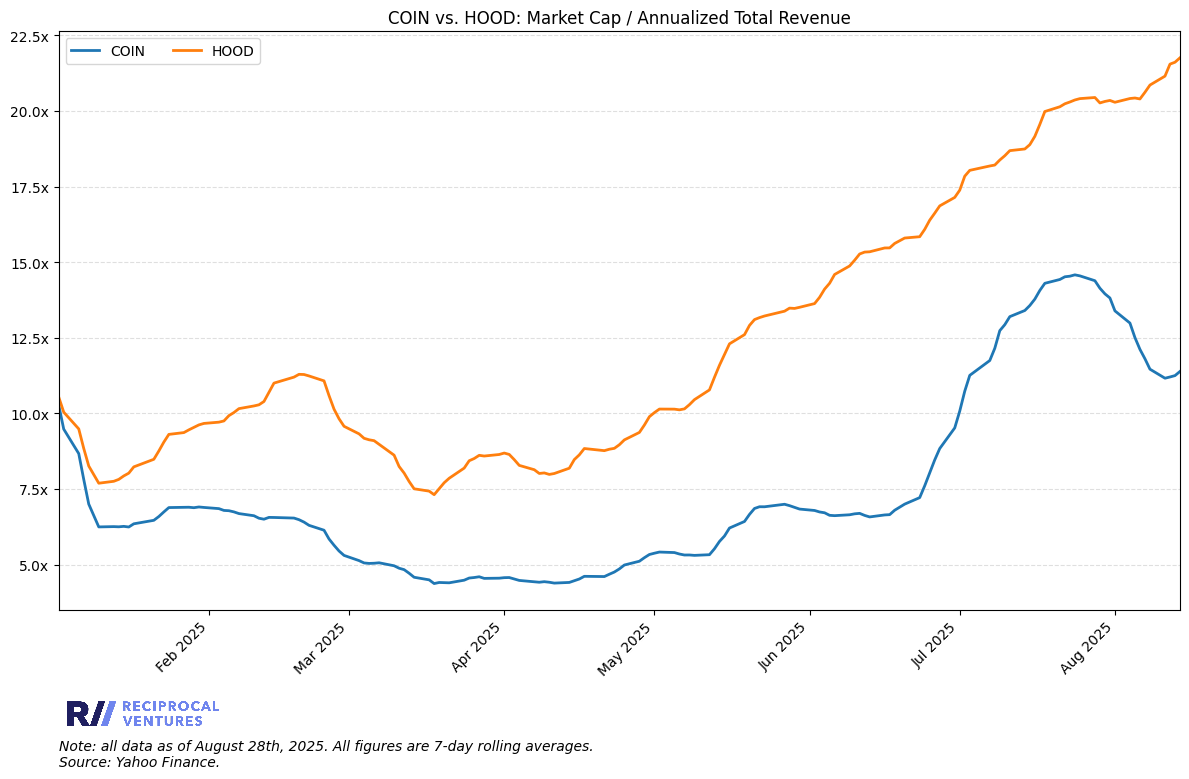

Cohort MCAP / Annualized Total Revenue Statistics:
Median: 8x
Mean: 10x
80th Percentile: 14x
20th Percentile: 7x
Latest Multiple: 17x
Note: statistics are based on simple daily averages of multiples



In [80]:
# Call the function
tickers   = ['COIN', 'HOOD']
metric = 'Total Revenue' # can also include 'EBITDA'

cex_stats = plot_mcap_to_annualized_metric_multiple(start_date, tickers, metric)

In [81]:
start_date = format_date_with_suffix(start_date)

combined_stats = pd.DataFrame({
    f'{breakout_asset[1]}':              breakout_stats,
    'CEXs': cex_stats,
    'Perps DEXs':                perps_stats,
    'Smart Contract Platforms': scp_stats

})

combined_stats.index = [
    'Median',
    '80th Percentile',
    '20th Percentile',
    'Most Recent'
]

styled = (
    combined_stats
      .style
      .set_caption(f"{top_metric} / Annualized {bottom_metric} Multiples by Cohort")
      .set_table_styles([
          {"selector": "caption",
           "props": [
             ("font-weight", "bold"),
             ("caption-side", "top"),
             ("text-decoration", "underline")
           ]},
          {"selector": "thead th", "props": [("font-weight", "normal")]},
          {"selector": "tbody th", "props": [("font-weight", "normal")]}
      ], overwrite=False)
      .format(lambda v: f"{v:,.0f}x" if pd.notnull(v) else "")
)

display(styled)


print(f"""
Notes:
 • All data from {start_date} to {date}.
 • CEXs include: Coinbase and Robinhood. Represented as MCap / Annualized Revenue.
 • Perp DEXs includes: Drift, dYdX, GMX, and Jupiter.
 • Smart Contract Platforms includes: Arbitrum, Avalanche,
   BNB, Ethereum, Solana, Optimism, Polygon, TON, and Tron.
 • Perps DEXs and Smart Contract Platforms multiples are
   daily FDV-weighted averages of all listed protocols.
 
 Sources: DefiLlama and Messari.
""")

,Hyperliquid,CEXs,Perps DEXs,Smart Contract Platforms
Median,39x,8x,9x,714x
80th Percentile,62x,14x,16x,"1,001x"
20th Percentile,27x,7x,6x,483x
Most Recent,27x,17x,"1,096x",955x



Notes:
 • All data from January 1st, 2025 to August 28th, 2025.
 • CEXs include: Coinbase and Robinhood. Represented as MCap / Annualized Revenue.
 • Perp DEXs includes: Drift, dYdX, GMX, and Jupiter.
 • Smart Contract Platforms includes: Arbitrum, Avalanche,
   BNB, Ethereum, Solana, Optimism, Polygon, TON, and Tron.
 • Perps DEXs and Smart Contract Platforms multiples are
   daily FDV-weighted averages of all listed protocols.
 
 Sources: DefiLlama and Messari.



In [82]:
def annualized_fees_vs_price_to_annualized_fees(asset_id, asset_name, start_date, date):
    # Load revenue data
    with open(f"raw-data/defillama-raw-data/dailyFees_data/{asset_id}_Fees.json", "r") as f:
        rev_data = json.load(f)
    
    rev_df = pd.DataFrame(rev_data["totalDataChart"], columns=["timestamp", "fees"])
    rev_df["date"] = pd.to_datetime(rev_df["timestamp"], unit="s")
    rev_df = rev_df[["date", "fees"]]
    
    # Annualize revenue and calculate trailing 7-day average
    rev_df['annualized-fees'] = rev_df['fees'] * 365
    rev_df["annualized-fees-7d"] = rev_df["annualized-fees"].rolling(window=7, min_periods=1).mean()

    # Load mcap data
    with open(f"raw-data/messari-raw-data/asset-data/{asset_id}_marketcap.json", 'r') as f:
        mcap_data = json.load(f)
    
    points = mcap_data['data']['points']
    mcap_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])
    mcap_df["date"] = pd.to_datetime(mcap_df["timestamp"], unit="s")
    mcap_df = mcap_df[['date','fully-diluted-marketcap']]
    mcap_df['FDV-7d'] = mcap_df['fully-diluted-marketcap'].rolling(window=7).mean()
    
    # Merge datasets
    df = pd.merge(rev_df, mcap_df, on="date", how="inner")
    
    # Calculate P/S ratio and trailing 7-day average
    df['FDV-to-annualized-fees-multiple'] = df['fully-diluted-marketcap'] / df['annualized-fees']
    df['FDV-to-annualized-fees-multiple-7d'] = df['FDV-to-annualized-fees-multiple'].rolling(window=7, min_periods=1).mean()

    # Filter the data for a given time period
    plot_df = df[df['date'] >= start_date]
    
    # 6) Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Area: Hyperliquid market share
    ax1.fill_between(
        plot_df["date"], plot_df["annualized-fees-7d"],
        color="#a4a2a8", alpha=1,
        label="Annualized Fees"
    )
    ax1.set_ylabel("Annualized Fees")
    ax1.set_ylim(bottom=0)
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}b'))
    
    # Monthly ticks, lighter crowding
    ax1.xaxis.set_major_locator(YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
    
    # Line: FDV / annualzied revenue
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df["date"], plot_df["FDV-to-annualized-fees-multiple-7d"],
        color="#1f1f60", linewidth=2,
        label="FDV / Annualized Fees"
    )
    ax2.set_ylabel("FDV / Annualized Fees")
    ax2.set_ylim(bottom=0)
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}x'))

    # no extra padding
    ax1.margins(x=0)
    
    # Title, grid & legend
    ax1.set_title(f"{asset_name}: Annualized Fees vs. FDV / Annualized Fees", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.075, -0.04, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama and Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/{asset_id}-annualized-fees_vs_FDV-to-annualized-fees_7d.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(10))

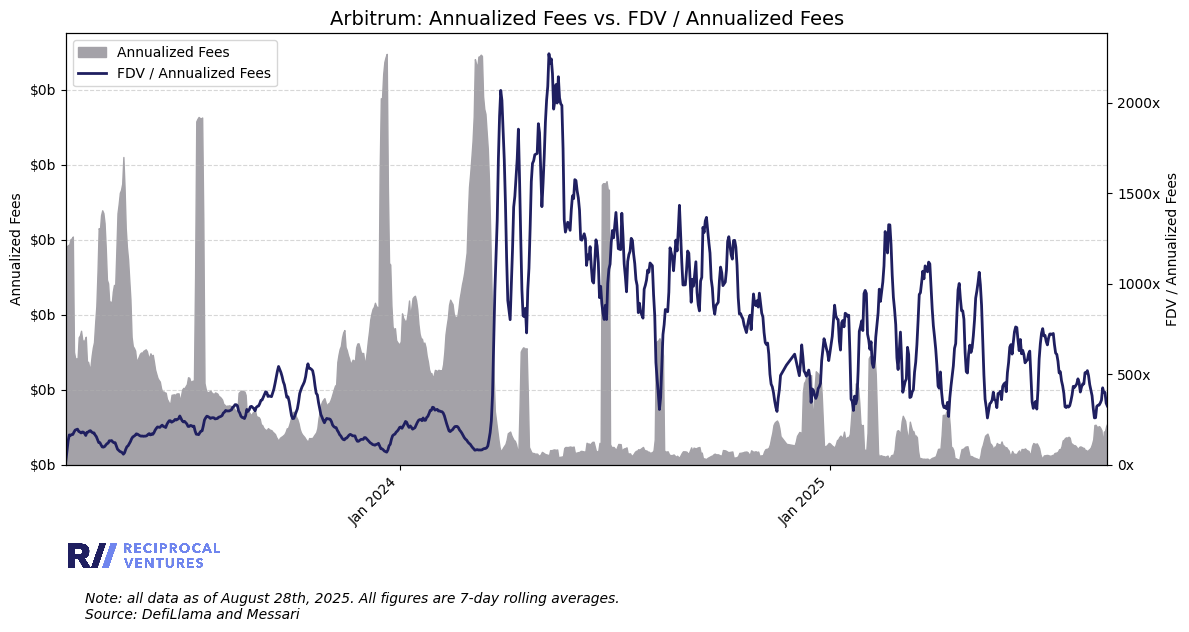

          date    fees  annualized-fees  annualized-fees-7d  \
838 2025-08-16   18598          6788270        2.544874e+07   
839 2025-08-17   24952          9107480        2.552085e+07   
840 2025-08-18   50697         18504405        2.586838e+07   
841 2025-08-19   47898         17482770        2.475753e+07   
842 2025-08-20   43469         15866185        2.316910e+07   
843 2025-08-21   25017          9131205        1.369365e+07   
844 2025-08-22  216505         79024325        2.227209e+07   
845 2025-08-23   23037          8408505        2.250355e+07   
846 2025-08-24   92035         33592775        2.600145e+07   
847 2025-08-25   84607         30881555        2.776962e+07   

     fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
838             4.929954e+09  4.919203e+09                       726.245941   
839             5.367102e+09  5.018807e+09                       589.307076   
840             5.113962e+09  5.126385e+09                       276.

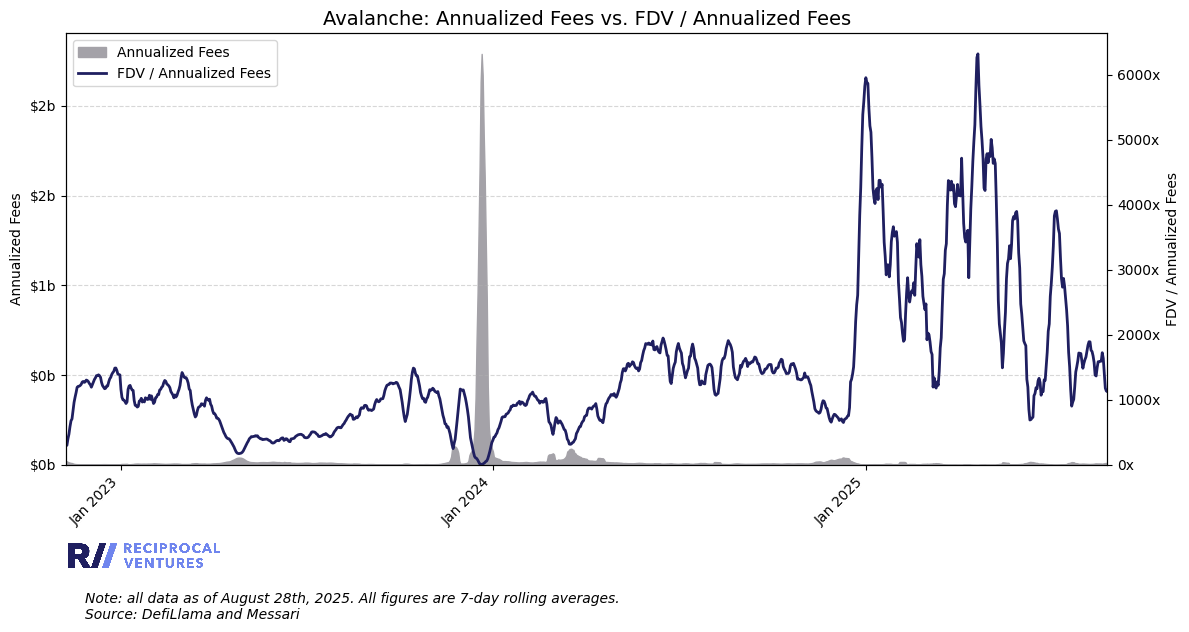

           date   fees  annualized-fees  annualized-fees-7d  \
1013 2025-08-17  11721          4278165        8.435619e+06   
1014 2025-08-18  20547          7499655        8.482756e+06   
1015 2025-08-19  20905          7630325        8.320696e+06   
1016 2025-08-20  25638          9357870        8.189818e+06   
1017 2025-08-21  17328          6324720        6.991366e+06   
1018 2025-08-22  62840         22936600        8.879772e+06   
1019 2025-08-23  28975         10575875        9.800459e+06   
1020 2025-08-24  30959         11300035        1.080358e+07   
1021 2025-08-25  25719          9387435        1.107327e+07   
1022 2025-08-26  23891          8720215        1.122896e+07   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
1013             1.149230e+10  1.111330e+10                      2686.268049   
1014             1.085783e+10  1.117198e+10                      1447.776634   
1015             1.023981e+10  1.102004e+10                      1

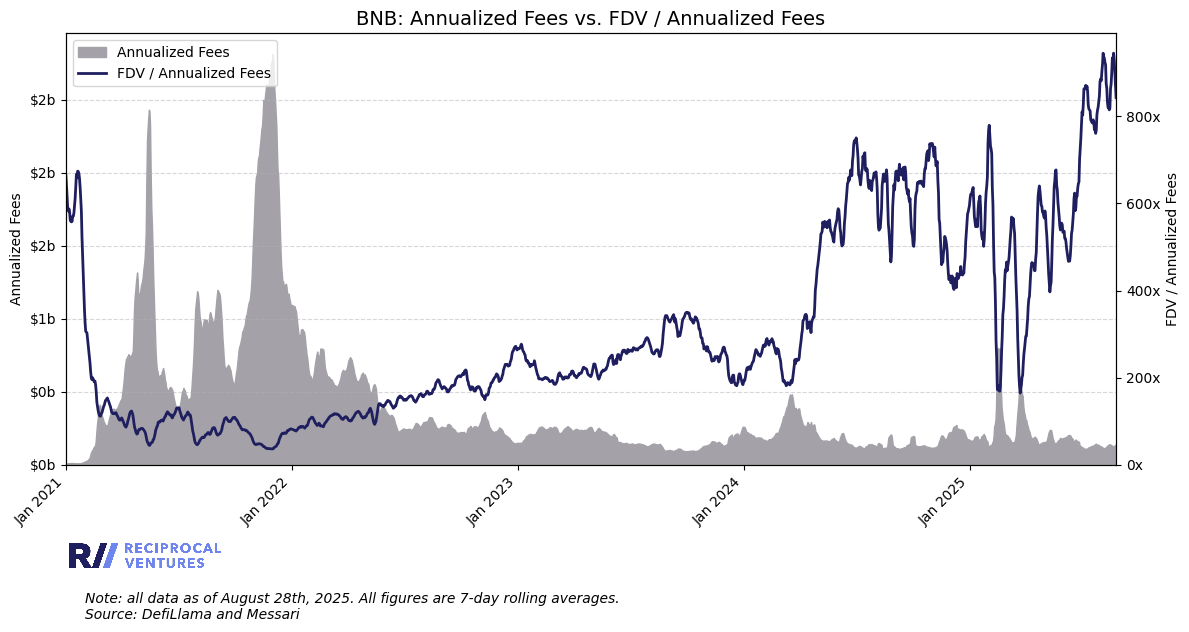

           date    fees  annualized-fees  annualized-fees-7d  \
1688 2025-08-16  279417        101987205        1.374011e+08   
1689 2025-08-17  310585        113363525        1.371355e+08   
1690 2025-08-18  342018        124836570        1.337750e+08   
1691 2025-08-19  338761        123647765        1.278159e+08   
1692 2025-08-20  401680        146613200        1.291049e+08   
1693 2025-08-21  388643        141854695        1.259497e+08   
1694 2025-08-22  440150        160654750        1.304225e+08   
1695 2025-08-23  359168        131096320        1.345810e+08   
1696 2025-08-24  399790        145923350        1.392324e+08   
1697 2025-08-25  417541        152402465        1.431704e+08   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
1688             1.168917e+11  1.154528e+11                      1146.140343   
1689             1.192427e+11  1.164266e+11                      1051.861417   
1690             1.180597e+11  1.172592e+11            

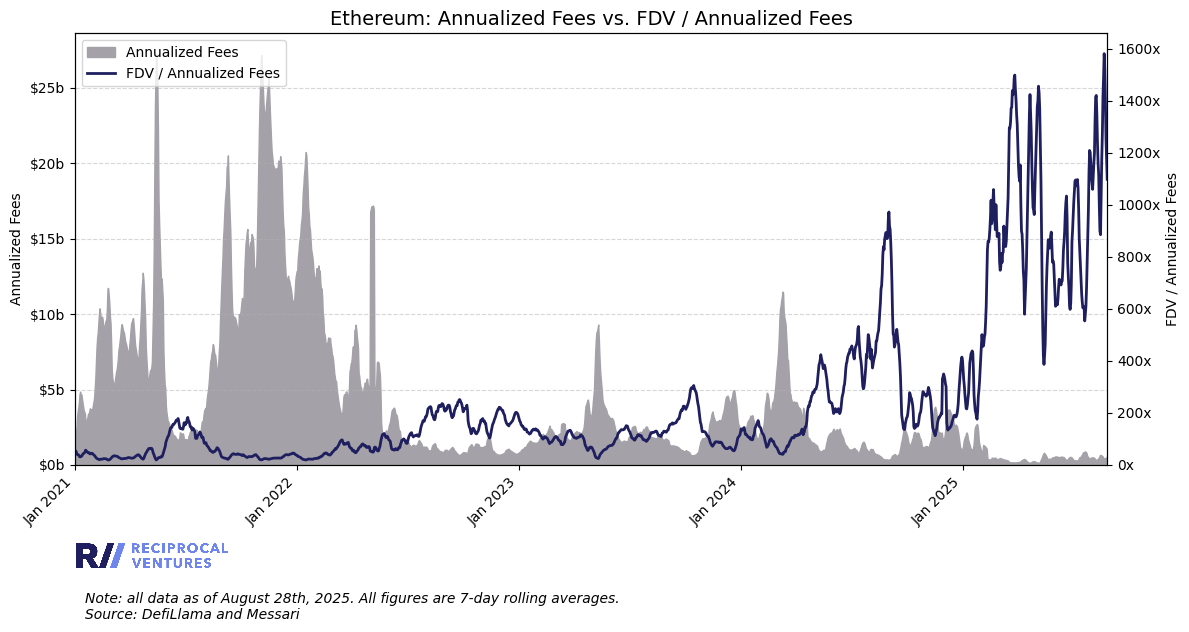

           date     fees  annualized-fees  annualized-fees-7d  \
1689 2025-08-17   623984        227754160        6.222263e+08   
1690 2025-08-18   848006        309522190        5.930823e+08   
1691 2025-08-19   792710        289339150        5.202851e+08   
1692 2025-08-20  1309256        477878440        4.461478e+08   
1693 2025-08-21  1180143        430752195        3.645156e+08   
1694 2025-08-22  2878303       1050580595        4.346950e+08   
1695 2025-08-23  1268741        463090465        4.641310e+08   
1696 2025-08-24  1212856        442692440        4.948365e+08   
1697 2025-08-25  1256579        458651335        5.161407e+08   
1698 2025-08-26  1318284        481173660        5.435456e+08   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
1689             5.402402e+11  5.425188e+11                      2372.032144   
1690             5.210061e+11  5.440791e+11                      1683.259394   
1691             4.917757e+11  5.351708e+11 

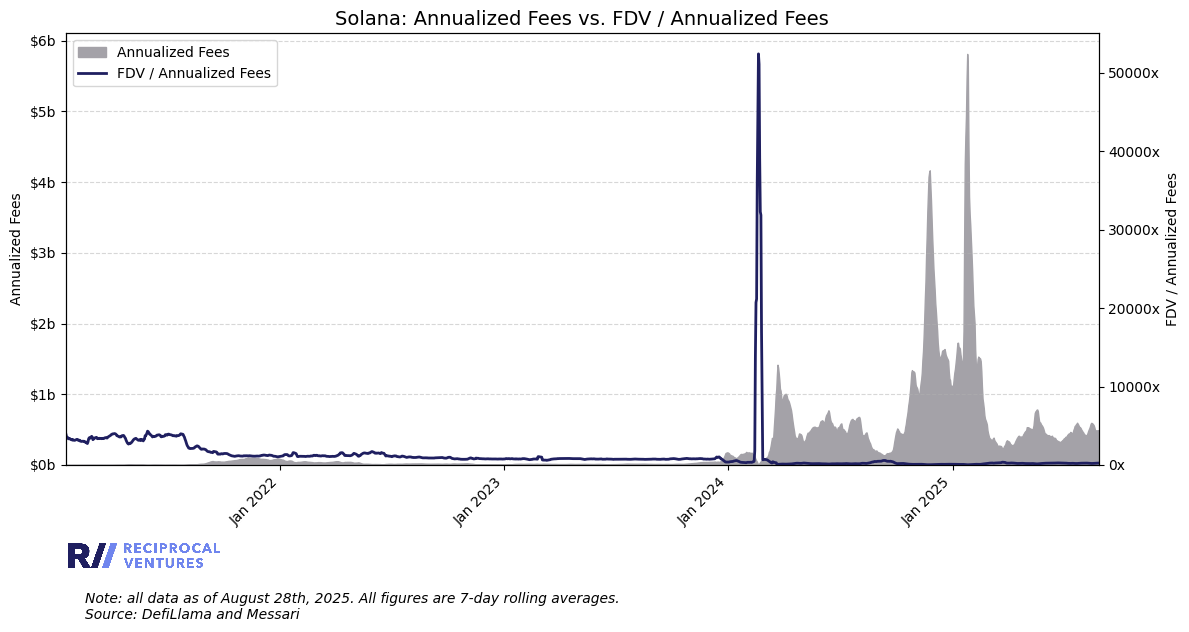

           date     fees  annualized-fees  annualized-fees-7d  \
1671 2025-08-17  1119798        408726270        5.749296e+08   
1672 2025-08-18  1353465        494014725        5.614652e+08   
1673 2025-08-19  1316572        480548780        5.348761e+08   
1674 2025-08-20  1266785        462376525        5.002544e+08   
1675 2025-08-21  1592643        581314695        4.885534e+08   
1676 2025-08-22  1498225        546852125        4.887862e+08   
1677 2025-08-23  1182558        431633670        4.864953e+08   
1678 2025-08-24  1215612        443698380        4.914913e+08   
1679 2025-08-25  1319766        481714590        4.897341e+08   
1680 2025-08-26  1341372        489600780        4.910273e+08   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
1671             1.161467e+11  1.152030e+11                       284.167453   
1672             1.112469e+11  1.159215e+11                       225.189499   
1673             1.070293e+11  1.145719e+11 

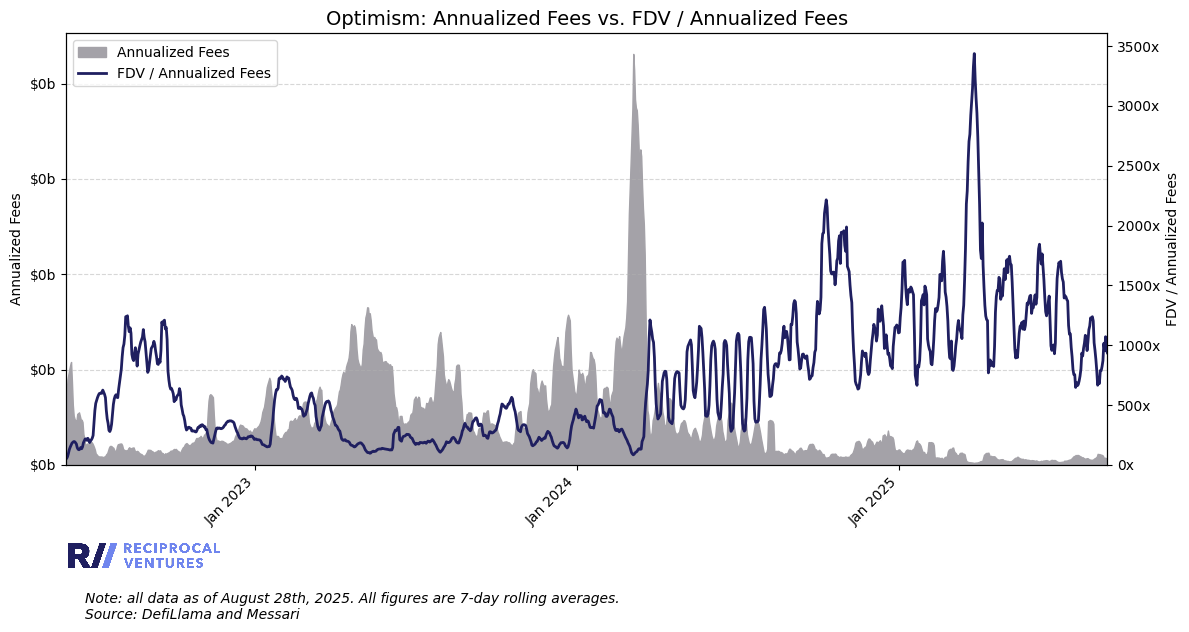

           date   fees  annualized-fees  annualized-fees-7d  \
1173 2025-08-16  15518          5664070        5.758605e+06   
1174 2025-08-17   5834          2129410        5.443141e+06   
1175 2025-08-18  10590          3865350        5.427915e+06   
1176 2025-08-19   8249          3010885        5.196870e+06   
1177 2025-08-20   7999          2919635        4.877286e+06   
1178 2025-08-21   6690          2441850        3.350022e+06   
1179 2025-08-22  19187          7003255        3.862065e+06   
1180 2025-08-23   6927          2528355        3.414106e+06   
1181 2025-08-24  12308          4492420        3.751679e+06   
1182 2025-08-25  12330          4500450        3.842407e+06   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
1173             3.181608e+09  3.322715e+09                       561.717681   
1174             3.269997e+09  3.305491e+09                      1535.635432   
1175             3.099850e+09  3.288693e+09                       

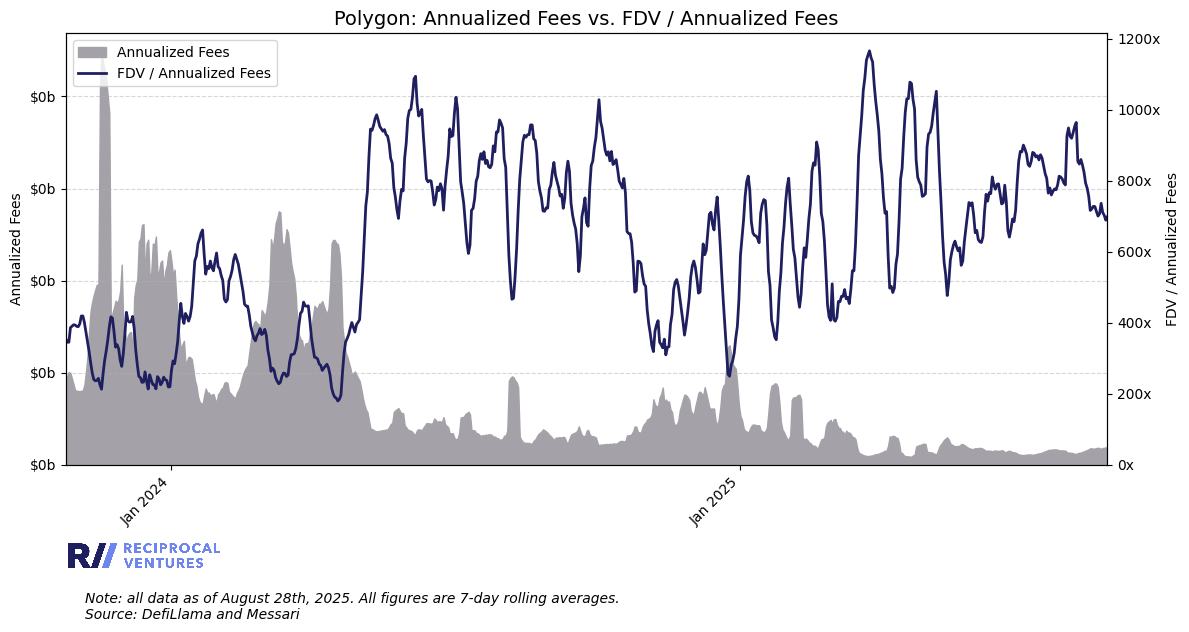

          date   fees  annualized-fees  annualized-fees-7d  \
660 2025-08-16   7846          2863790        3.547435e+06   
661 2025-08-17   8599          3138635        3.560419e+06   
662 2025-08-18  12450          4544250        3.700214e+06   
663 2025-08-19  10540          3847100        3.734367e+06   
664 2025-08-20   9448          3448520        3.674142e+06   
665 2025-08-21   9000          3285000        3.491016e+06   
666 2025-08-22  13008          4747920        3.696459e+06   
667 2025-08-23   8860          3233900        3.749332e+06   
668 2025-08-24   9978          3641970        3.821237e+06   
669 2025-08-25  10125          3695625        3.700005e+06   

     fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
660             2.483960e+09  2.534051e+09                       867.368028   
661             2.587228e+09  2.542740e+09                       824.316456   
662             2.718022e+09  2.576010e+09                       598.123234   
6

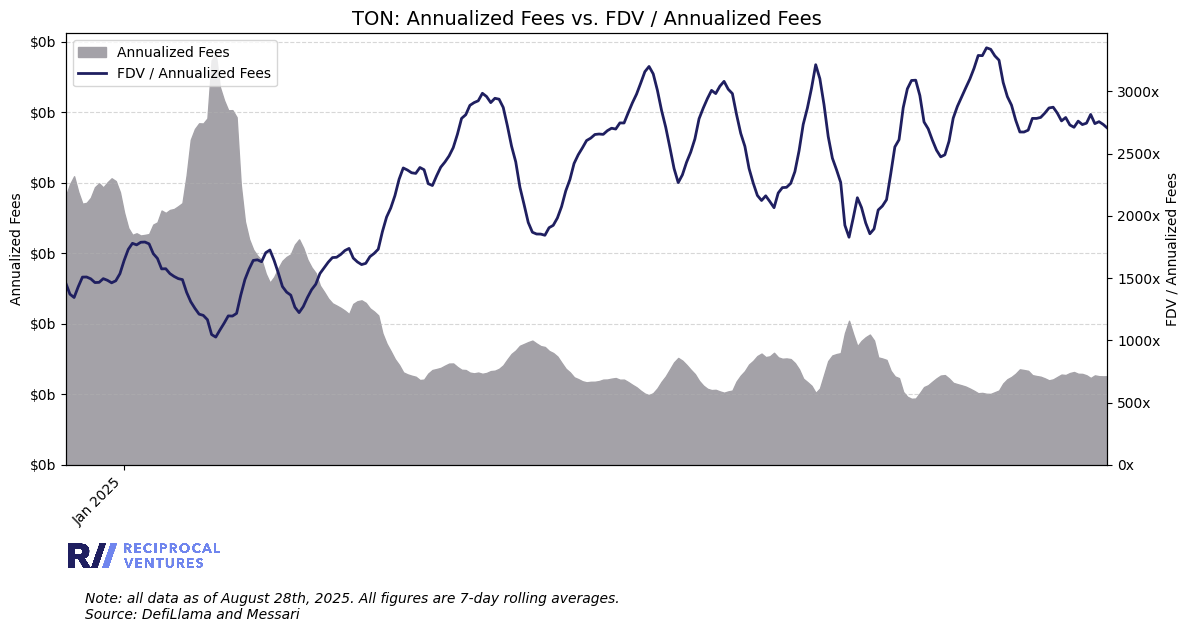

          date   fees  annualized-fees  annualized-fees-7d  \
241 2025-08-16  17843          6512695        6.516397e+06   
242 2025-08-17  16093          5873945        6.589814e+06   
243 2025-08-18  16226          5922490        6.464202e+06   
244 2025-08-19  18061          6592265        6.455703e+06   
245 2025-08-20  17389          6346985        6.356006e+06   
246 2025-08-21  15754          5750210        6.164433e+06   
247 2025-08-22  20431          7457315        6.350844e+06   
248 2025-08-23  16740          6110100        6.293330e+06   
249 2025-08-24  15879          5795835        6.282171e+06   
250 2025-08-25  16352          5968480        6.288741e+06   

     fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
241             1.778903e+10  1.766572e+10                      2731.439881   
242             1.809201e+10  1.779078e+10                      3080.044787   
243             1.711494e+10  1.776377e+10                      2889.821917   
2

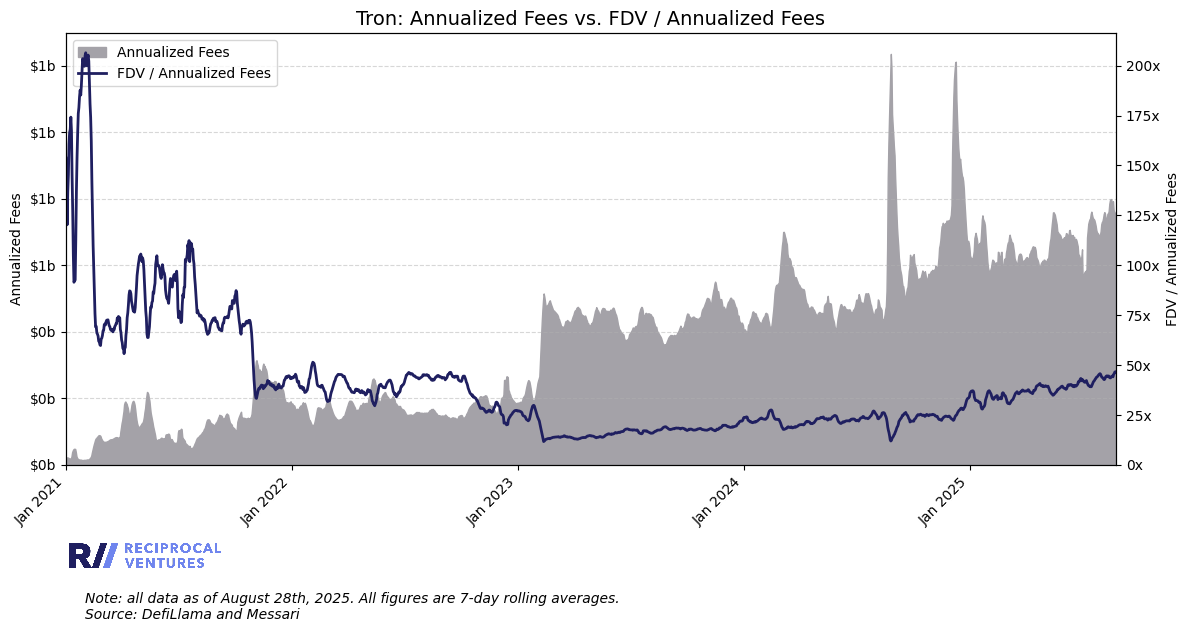

           date     fees  annualized-fees  annualized-fees-7d  \
1688 2025-08-16  1621133        591713545        7.993038e+08   
1689 2025-08-17  1398122        510314530        7.994819e+08   
1690 2025-08-18  2361996        862128540        7.895835e+08   
1691 2025-08-19  2408094        878954310        7.875959e+08   
1692 2025-08-20  2489618        908710570        7.930281e+08   
1693 2025-08-21  2060556        752102940        7.668829e+08   
1694 2025-08-22  2250422        821404030        7.607612e+08   
1695 2025-08-23  1540791        562388715        7.565719e+08   
1696 2025-08-24  1436133        524188545        7.585540e+08   
1697 2025-08-25  2232686        814930390        7.518114e+08   

      fully-diluted-marketcap        FDV-7d  FDV-to-annualized-fees-multiple  \
1688             3.295247e+10  3.322956e+10                        55.689895   
1689             3.348405e+10  3.343599e+10                        65.614541   
1690             3.318510e+10  3.350863e+10 

In [83]:
smart_contract_platforms = {
          'arbitrum': 'Arbitrum',
          'avalanche': 'Avalanche',
          'bnb': 'BNB',
          'ethereum': 'Ethereum',
          'solana': 'Solana',
          'optimism': 'Optimism',
          'polygon': 'Polygon',
          'ton': 'TON',
          'tron': 'Tron'
             }
start_date = '2021-01-01'

for asset_id, asset_name in smart_contract_platforms.items():
    annualized_fees_vs_price_to_annualized_fees(asset_id, asset_name, start_date, date)

In [84]:
# Funciton for plotting OI vs circulating supply for a given asset


def oi_vs_circulating_mcap_vs_funding_rate(asset_id, asset_name, start_date, date):
    # Load price data
    with open(f'raw-data/messari-raw-data/asset-data/{asset_id}_price.json', 'r') as f:
        price_data = json.load(f)

    points = price_data['data']['points']
    price_df = pd.DataFrame(points, columns=[
    'timestamp',
    'open',
    'high',
    'low',
    'close',
    'volume'
    ])
    price_df["date"] = pd.to_datetime(price_df["timestamp"], unit="s")
    price_df = price_df[['date','close']]

    # Calculate traling 7-dday average
    price_df['close-7d'] = price_df['close'].rolling(window=7).mean()

    # Load supply data
    with open(f'raw-data/messari-raw-data/asset-data/{asset_id}_supply.json', 'r') as f:
        supply_data = json.load(f)

    points = supply_data['data']['points']
    supply_df = pd.DataFrame(points, columns=[
    'timestamp',
    'circulating-supply',
    'total-supply'
    ])
    supply_df["date"] = pd.to_datetime(supply_df["timestamp"], unit="s")
    supply_df = supply_df[['date','circulating-supply']]

    # Calculate traling 7-dday average
    supply_df['circulating-supply-7d'] = supply_df['circulating-supply'].rolling(window=7).mean()
    
    # Load oi data
    with open(f"raw-data/messari-raw-data/asset-data/{asset_id}_futures-open-interest.json", "r") as f:
        oi_data = json.load(f)
    
    points = oi_data['data']['points']
    oi_df = pd.DataFrame(points, columns=[
        'timestamp',
        'open-interest'
    ])
    oi_df["date"] = pd.to_datetime(oi_df["timestamp"], unit="s")
    oi_df = oi_df[['date','open-interest']]
    oi_df['open-interest-7d'] = oi_df['open-interest'].rolling(window=7).mean()
    
    # Load mcap data
    with open(f"raw-data/messari-raw-data/asset-data/{asset_id}_marketcap.json", 'r') as f:
        mcap_data = json.load(f)
    
    points = mcap_data['data']['points']
    mcap_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])
    mcap_df["date"] = pd.to_datetime(mcap_df["timestamp"], unit="s")
    mcap_df = mcap_df[['date','circulating-marketcap']]
    mcap_df['circulating-marketcap-7d'] = mcap_df['circulating-marketcap'].rolling(window=7).mean()

    # Load fundring rate data
    with open (f'raw-data/messari-raw-data/asset-data/{asset_id}_futures-funding-rate.json', 'r') as f:
        rate_data = json.load(f)

    points = rate_data['data']['points']
    rate_df = pd.DataFrame(points, columns=[
        'timestamp',
        "funding-rate-open-interest",
        "funding-rate-volume"
    ])
    rate_df['date'] = pd.to_datetime(rate_df['timestamp'], unit='s')
    rate_df = rate_df[['date', 'funding-rate-open-interest']]
    rate_df['funding-rate-open-interest-7d'] = rate_df['funding-rate-open-interest'].rolling(window=7).mean()
    
    # Merge datasets
    step1_df = pd.merge(price_df, supply_df, on="date", how="inner")
    step2_df = pd.merge(step1_df, oi_df, on='date', how='inner')
    step3_df = pd.merge(step2_df, mcap_df, on='date', how='inner')
    df = pd.merge(step3_df, rate_df, on='date', how='inner')
    df['oi_as_%_circ_mcap'] = df['open-interest'] / df['circulating-marketcap'] * 100 # Multiply by 100 to convert to % terms
    df['oi_as_%_circ_mcap_7d'] = df['oi_as_%_circ_mcap'].rolling(window=7).mean()

    # set cutoff date
    df = df[df["date"] >= start_date].reset_index(drop=True)
    
    # Drop any rows without a full 7‑day average, plus the very last day
    plot_df = df[df["open-interest-7d"].notna()].iloc[:-1]

    # two rows: top for MCap + OI, bottom for funding rates
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(12, 8),
        sharex=True,
        gridspec_kw={'height_ratios': [3, 1],
                    'hspace':0.05}
    )

    # TOP PANEL: Circulating Market Cap (area) + Open Interest (line)

    # area: 7-day MCap
    ax_top.fill_between(
        plot_df["date"],
        plot_df["close"],
        color="#a4a2a8", alpha=1,
        label="Close Price"
    )
    ax_top.set_ylabel("Close Price")
    ax_top.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x:,.2f}')
    )
    ax_top.set_ylim(0)

    # line: 7-day OI on a second y-axis
    ax_oi = ax_top.twinx()
    ax_oi.plot(
        plot_df["date"],
        plot_df["circulating-supply"],
        color="#1f1f60", linewidth=2,
        label="Circulating Supply"
    )
    ax_oi.set_ylabel("Circulating Supply")
    ax_oi.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x/1e6:,.1f}m')
    )

    # date formatting
    ax_top.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
    ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax_top.get_xticklabels(), rotation=45, ha="right")


    # BOTTOM PANEL: Funding Rate (OI-weighted)

    ax_bot.plot(
        plot_df['date'],
        plot_df['funding-rate-open-interest'],
        color="black", linewidth=1.2,
        label="Funding Rate"
    )
    ax_bot.set_ylabel("Funding Rate")
    ax_bot.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x*10000:,.0f}bps')
    )
    
    # line: add OI as % of Circ. Mcap to bottom chart
    ax_perc = ax_bot.twinx()
    ax_perc.plot(
        plot_df["date"],
        plot_df["oi_as_%_circ_mcap"],
        color="red", linewidth=1.2,
        label="OI as % of Circ. Mcap"
    )
    ax_perc.set_ylabel("OI (% Circ. Mcap)")
    ax_perc.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x:,.0f}%')
    )
    ax_perc.set_ylim(0)

    # 1) remove horizontal margins
    ax_top.margins(x=0)
    ax_bot.margins(x=0)

    # 3) bottom axis: month & two-digit year
    from matplotlib.dates import MonthLocator, DateFormatter

    ax_bot.xaxis.set_major_locator(MonthLocator())
    ax_bot.xaxis.set_major_formatter(DateFormatter("%b %y"))
    plt.setp(ax_bot.get_xticklabels(), rotation=45, ha="right")

     # ─── TITLES ───
    ax_top.set_title(f"{asset_name}: Price, Circulating Supply, and Open Interest", fontsize=14)

    # Pull legend handles from both axes
    h1, l1 = ax_top.get_legend_handles_labels()
    h2, l2 = ax_oi.get_legend_handles_labels()
    h3, l3 = ax_bot.get_legend_handles_labels()
    h4, l4 = ax_perc.get_legend_handles_labels()
    handles = h1 + h2 + h3 + h4
    labels  = l1 + l2 + l3 + l4

    # ─── make room at the bottom ───
    fig.subplots_adjust(bottom=0.2)

    # ─── FIGURE‐LEVEL LEGEND ───
    legend = fig.legend(
        handles, labels,
        loc="lower center",
        ncol=2,
        frameon=True,
        bbox_to_anchor=(0.5, 0.06),
        fontsize=10
    )
    # give it a thin black border
    frame = legend.get_frame()
    frame.set_edgecolor("black")
    frame.set_linewidth(0.5)
    frame.set_alpha(1)

    # ─── SMALLER LOGO, ALIGNED TO THE LEFT ───
    # position is in axis‐coordinates of ax_bot: x=0.075, y slightly below the axis
    add_logo(ax_bot, position=(0.075, -0.6), zoom=0.1)

    # ─── FOOTNOTE, SAME LEFT MARGIN ───
    fig.text(
        0.12, 0.03,
        f"Note: all data as of {date}.\nFunding rate is OI-weighted.\nSource: Messari",
        ha="left",
        fontsize=8,
        style="italic"
    )

    plt.savefig(
        f"{plots_filepath}/{asset_name}_price_vs_circ-supply_vs_funding-rate_vs_oi.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    print(plot_df.tail(5))

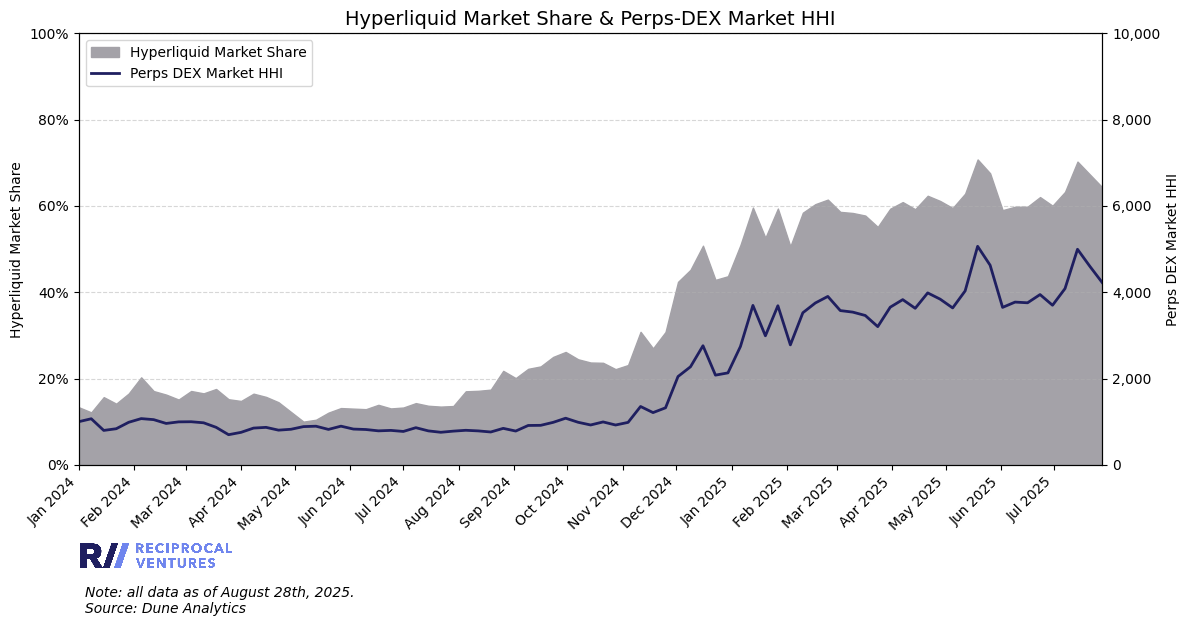

In [85]:
def plot_perpetual_volumes_from_json(json_path):
    # Load & parse the weekly JSON
    with open(json_path, 'r') as f:
        js = json.load(f)
    rows = js['result']['rows']
    df_w = pd.DataFrame(rows)
    # parse week → datetime
    df_w['date'] = pd.to_datetime(df_w['week'], utc=True)
    
    # Pivot so each row is a week, each column a product
    weekly = (
        df_w
        .pivot_table(
            index='date',
            columns='product_name',
            values='volume',
            aggfunc='sum'
        )
        .fillna(0)
    )
    
    # Compute total weekly volume & drop any weeks with zero total
    weekly['total_volume'] = weekly.sum(axis=1)
    weekly = weekly[weekly['total_volume'] > 0]

    # Market share (Hyperliquid) & HHI
    weekly['market_share'] = weekly['Hyperliquid Perps'] / weekly['total_volume'] * 100
    shares = weekly.drop(columns=['total_volume','market_share']).div(weekly['total_volume'], axis=0) * 100
    weekly['hhi'] = (shares ** 2).sum(axis=1)
    plot_df = weekly

    # Filter by index
    plot_df = plot_df[plot_df.index >= pd.to_datetime('2024-01-01', utc=True)]

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Area: Hyperliquid 7-week avg share
    ax1.fill_between(
        plot_df.index, plot_df['market_share'],
        color="#a4a2a8", alpha=1,
        label="Hyperliquid Market Share"
    )
    ax1.set_ylabel("Hyperliquid Market Share")
    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_formatter(PercentFormatter())

    # X-axis from first → last
    ax1.set_xlim(plot_df.index[0], plot_df.index[-1])
    ax1.margins(x=0)
    fig.subplots_adjust(left=0.07)

    # Monthly tick locator & formatter
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Line: Perps-DEX HHI
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df.index, plot_df['hhi'],
        color="#1f1f60", linewidth=2,
        label="Perps DEX Market HHI"
    )
    ax2.set_ylabel("Perps DEX Market HHI")
    ax2.set_ylim(0, 10_000)
    ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    # Title, grid & legend
    ax1.set_title(
        "Hyperliquid Market Share & Perps-DEX Market HHI",
        fontsize=14
    )
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    # Add logo & footer text
    add_logo(ax1, position=(0.075, -0.21))
    latest = plot_df.index[-1].strftime("%b %d, %Y")
    plt.figtext(
        0.075, -0.03,
        f"Note: all data as of {date}.\nSource: Dune Analytics",
        ha="left", fontsize=10, style="italic"
    )

    # tighten & save
    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(
        f"{plots_filepath}/hyperliquid_marketshare_hhi_7w.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# Usage
plot_perpetual_volumes_from_json("raw-data/dune-raw-data/dune_weekly-perps-dex-volumes.json")


In [86]:
def infaltion_vs_change_in_inflation(asset_id, asset_name, start_date, date):
    # Load supply data
    with open(f'raw-data/messari-raw-data/asset-data/{asset_id}_supply.json', 'r') as f:
        supply_data = json.load(f)

    points = supply_data['data']['points']
    supply_df = pd.DataFrame(points, columns=[
    'timestamp',
    'circulating-supply',
    'total-supply'
    ])
    supply_df["date"] = pd.to_datetime(supply_df["timestamp"], unit="s")
    supply_df = supply_df[['date','total-supply']]
    supply_df['delta-total-supply'] = supply_df['total-supply'].diff(periods=30)
    print(supply_df.tail(10))

In [87]:
start_date = '2022-01-01'
asset_id = 'ethereum'
asset_name = 'Ethereum'

infaltion_vs_change_in_inflation(asset_id, asset_name, start_date, date)

           date  total-supply  delta-total-supply
1691 2025-08-19  1.207078e+08        -4239.716098
1692 2025-08-20  1.207078e+08        -4188.464603
1693 2025-08-21  1.207077e+08        -4052.339152
1694 2025-08-22  1.207076e+08        -3894.270554
1695 2025-08-23  1.207075e+08        -3784.392438
1696 2025-08-24  1.207072e+08        -3936.984095
1697 2025-08-25  1.207072e+08        -3880.595092
1698 2025-08-26  1.207071e+08        -3883.024421
1699 2025-08-27  1.207070e+08        -3930.583656
1700 2025-08-28  1.207069e+08        -3978.140292


In [88]:
# Function to stablecoin mcap
def stablecoin_mcap_by_chain(asset, start_date, end_date, n):
    chain_colors = ['#1f1f60',
                    '#191F98',
                    '#313EA5',
                    '#4A5DB2',
                    '#637BBF',
                    '#7C9ACC',
                    '#94B9D9',
                    '#ADD8E6',
                    '#333333',
                    '#494949',
                    '#5F5F5F',
                    '#757575',
                    '#8A8A8A',
                    '#A0A0A0',
                    '#B6B6B6',
                    '#CCCCCC'
                   ]
    
    df_master = None
    
    counter = 0
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)

    with open(f"raw-data/defillama-raw-data/stablecoins/{asset}.json", 'r') as f:
        data = json.load(f)
    
    # Flatten records
    records = []
    for chain, chain_data in data.get('chainBalances', {}).items():
        for entry in chain_data.get('tokens', []):
            df_date = pd.to_datetime(entry.get('date'), unit='s')
            # Use circulating peggedUSD; if missing, fallback to bridgedTo peggedUSD
            value = entry.get('circulating', {}).get('peggedUSD')
            if value is None:
                value = entry.get('bridgedTo', {}).get('peggedUSD', 0)
            records.append({'date': df_date, 'chain': chain, 'peggedUSD': value})
    
    # Create DataFrame and pivot
    df_all = pd.DataFrame(records)
    df_pivot = df_all.pivot_table(index='date', columns='chain', values='peggedUSD', aggfunc='sum')
    df_pivot = df_pivot.ffill().sort_index()
    
    # Determine top_n chains *by the last date* in the index
    last_date   = df_pivot.index.max()
    last_values = df_pivot.loc[last_date]
    sorted_chains = last_values.sort_values(ascending=False)
    top_chains  = list(sorted_chains.index[:n])
    other_chains = list(sorted_chains.index[n:])
    
    # Build final DataFrame with 'Other' aggregation
    df_top = df_pivot[top_chains].copy()
    df_top['Other'] = df_pivot[other_chains].sum(axis=1)
    df_master = df_top.reset_index()

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')

    # Grab chain names
    chains = df_master.columns[1:].tolist()

    # Calculate 7-day trailing averages for each chain column
    df_master[chains] = df_master[chains].rolling(window=7, min_periods=1).mean()
    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[chain] for chain in chains]
    colors = chain_colors[:len(chains)]
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=chains,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000000:.0f}b'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.18))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    ax.set_title(f'{asset} Market Cap by Chain')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{asset}-mcap-by-chain.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

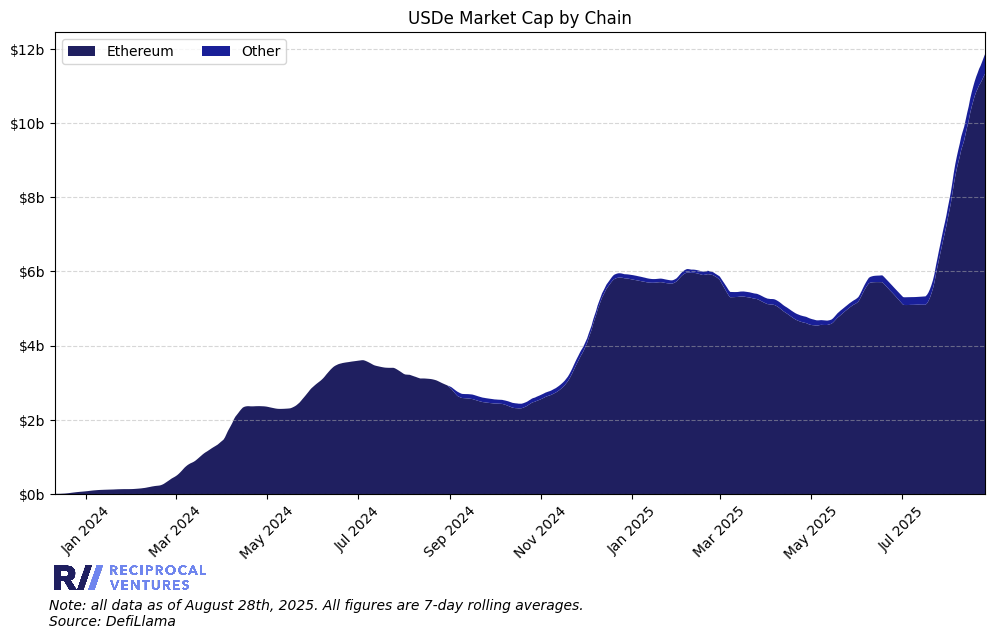

chain       date      Ethereum         Other
620   2025-08-22  1.101811e+10  4.422011e+08
621   2025-08-23  1.108006e+10  4.634810e+08
622   2025-08-24  1.116069e+10  4.870500e+08
623   2025-08-25  1.124905e+10  5.063769e+08
624   2025-08-26  1.132722e+10  5.309079e+08


In [89]:
asset = 'USDe'
start_date = '2023-01-01'
end_date = today
n = 1 # number of protocols to show, max is number pulled down in the raw data

stablecoin_mcap_by_chain(asset, start_date, end_date, n)

In [90]:
# Function for plotting cumulative fees or revenue
def cumulitative_metric(metric, assets):
    metric_id = 'Fees'
    if metric == 'dailyRevenue':
        metric_id = 'Revenue'

    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date)
    
    for asset_slug, asset_name in assets.items():
        with open(f'raw-data/defillama-raw-data/{metric}_data/{asset_slug}_{metric_id}.json', "r") as f:
            raw_data = json.load(f)
        
        df = pd.DataFrame(raw_data["totalDataChart"], columns=["timestamp", metric_id])
        df["date"] = pd.to_datetime(df["timestamp"], unit="s")
        df = df[["date", metric_id]]
        
        # Calculate cumulative revenue
        df[f"cumulative-{metric_id}"] = df[metric_id].cumsum()

        # Find first non-zero cumulative metric date and start time series then
        nonzero_dates = df.loc[df[f"cumulative-{metric_id}"] > 0, "date"]
        if not nonzero_dates.empty:
            first_nonzero_date = nonzero_dates.iloc[0]
            df = df.loc[df["date"] >= first_nonzero_date]
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        # Area: Circulating market cap
        ax.fill_between(
            df["date"], df[f"cumulative-{metric_id}"],
            color="#1f1f60", alpha=1,
            label=f"Cumulative {metric_id}"
        )
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:,.0f}m'))
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.margins(x=0) # no extra padding
        
        # Monthly ticks, lighter crowding
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %y'))
        plt.xticks(rotation=45)
        
        # Title, grid & legend
        ax.set_title(f"{asset_name} Cumulative {metric_id}", fontsize=14)
        
        # Save & show
        add_logo(ax, position=(0.075, -0.2))
        plt.figtext(0.06, -0.04, f"Note: all data as of {date}.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
        plt.tight_layout()
        plt.savefig(f"{plots_filepath}/{asset_name}_cumulative_{metric_id}.png", dpi=300, bbox_inches="tight")
        plt.show()
        
        last_val = df[f"cumulative-{metric_id}"].iloc[-1]
        last_metric = f'${last_val/1e6:,.1f}m'
        print(f"Latest {asset_name} Cumulative {metric_id}: {last_metric}")

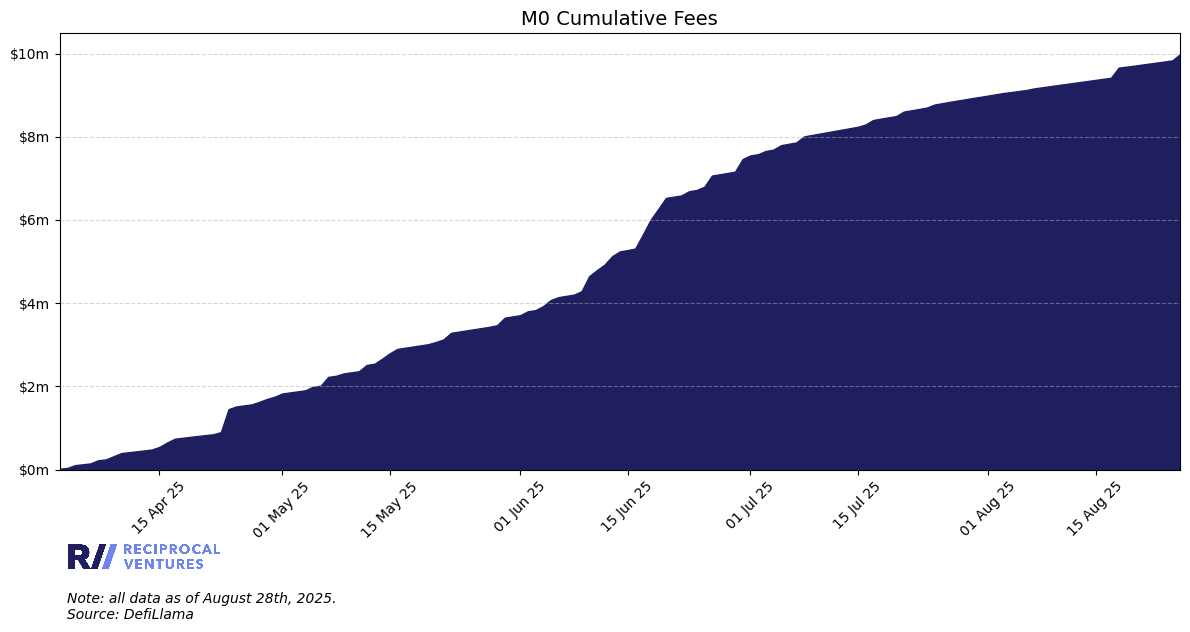

Latest M0 Cumulative Fees: $10.0m


In [91]:
metric = 'dailyFees' # 'dailyFees' or 'dailyRevenue'
assets = {'M0': 'M0'}

cumulitative_metric(metric, assets)

In [92]:
# Function to grab all networks listed on messari and save to a dictionary to be used in the pull_network_data function

def extract_from_list(file_path, metric_category, metric_extract, excluded_slugs, n):
    with open(file_path, 'r') as f:
        data = json.load(f)

    filtered = []
    datalist = data['data']['data']

    # Fixed the loop structure
    for entry in datalist:  # Iterate directly over the entries
        try:
            if entry["slug"] in excluded_slugs:
                continue
            metric_value = entry["metrics"][metric_category][metric_extract]  # Fixed: added "metrics" and used metric_value
            if metric_value is not None:  # Only include entries with valid metric values
                filtered.append((entry["slug"], entry["name"], metric_value))
        except (KeyError, TypeError):
            continue

    sorted_filtered = sorted(filtered, key=lambda x: x[2], reverse=True)
    top_dict = {slug: name for slug, name, _ in sorted_filtered[:n]}
    return top_dict

In [93]:
# call the function

file_path = 'raw-data/messari-raw-data/network-data/all_networks.json'
metric_category = 'ecosystem'
metric_extract = 'ecosystemCommits24Hour'
excluded_slugs = []
n = 20
extract_dict = extract_from_list(file_path, metric_category, metric_extract, excluded_slugs, n)

print(extract_dict)
print(f"Length: {len(extract_dict)}")

{'ethereum': 'Ethereum', 'internet-computer': 'Internet Computer', 'base': 'Base', 'arbitrum-one': 'Arbitrum', 'optimism': 'Optimism', 'solana': 'Solana', 'binance-smart-chain': 'BNB Chain', 'celo': 'Celo', 'stellar': 'Stellar', 'avalanche': 'Avalanche', 'kusama': 'Kusama', 'tron': 'TRON', 'filecoin': 'Filecoin', 'polygon-pos': 'Polygon', 'polkadot': 'Polkadot', 'ronin': 'Ronin', 'bitcoin': 'Bitcoin'}
Length: 17


In [94]:
# Function for pulling ecosystem metric data from messary by chain
def ecosystem_metric_by_network(metric, networks, start_date, rolling, n_assets, n_col):
    network_colors = ['#1f1f60',
                    '#191F98',
                    '#4A5DB2',
                    '#7C9ACC',
                    '#ADD8E6',
                    '#333333',
                    '#5F5F5F',
                    '#8A8A8A',
                    '#B6B6B6'
                   ]
    

    df_master = None
    
    for network_slug, network_name in networks.items():
        with open(f"raw-data/messari-raw-data/network-data/{network_slug}_ecosystem.json", 'r') as f:
            data = json.load(f)

        points = data['data']['points']
        eco_df = pd.DataFrame(points, columns=[
            'timestamp',
            'tvl-usd',
            'ecosystem-dex-volume-usd',
            'coreCommits24Hour',
            'activeDevelopers24Hour',
            'ecosystemCommits24Hour'
        ])
        eco_df["date"] = pd.to_datetime(eco_df["timestamp"], unit="s")
        eco_df = eco_df[['date',f'{metric[0]}']]
        eco_df[f'{network_name}'] = eco_df[f'{metric[0]}']

        # Keep only relevant columns
        eco_df = eco_df[['date',f'{network_name}']]

        # Merge dataframes
        df_master = eco_df if df_master is None else df_master.merge(eco_df, on='date', how='outer')
        df_master.fillna(0).infer_objects(copy=False)
    
    
    # Fill NaN values and set date as index
    df_master = df_master.fillna(0)
    df_master = df_master.set_index('date')
    
    # Cut df_master by timeframes
    start_date_dt = pd.to_datetime(start_date)
    df_plot = df_master[df_master.index >= start_date_dt]
    
    # Pick n networks and roll up the rest
    totals       = df_plot.sum(axis=0)
    top_assets   = totals.nlargest(n_assets).index.tolist()
    other_networks = [c for c in df_plot.columns if c not in top_assets]

    df_top = df_plot[top_assets].copy()
    df_top['Other'] = df_plot[other_networks].sum(axis=1)

    # determine stacking order:
    #    - take top_assets sorted by descending total (so largest is first → bottom)
    #    - then put 'Other' last → top
    ordered = totals[top_assets].sort_values(ascending=False).index.tolist()
    stack_cols = ordered + ['Other']

    # pick a grey for “Other”
    grey = '#CCCCCC'

    # build the colors list: use the existing palette for the top-N,
    # then force “Other” to grey
    colors = network_colors[:len(stack_cols)-1] + [grey]

    # normalize to 100% per day
    df_pct = df_top.div(df_top.sum(axis=1), axis=0)
    
    # Replace w/ 7-day rolling averages
    df_pct = df_pct.rolling(window=rolling, min_periods=1).mean()

    # now plot
    fig, ax = plt.subplots(figsize=(12,6))
    df_pct.plot.area(
        stacked=True,
        ax=ax,
        color=network_colors[:len(df_pct.columns)-1] + ['#CCCCCC'],
        alpha=0.8
    )

    ax.set_xlabel('')

     # y-axis as %
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(0,1)

    delta = (today - start_date_dt).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    elif delta < (31*18):
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    elif delta < (21 * 12 * 4):
        ax.xaxis.set_major_locator(MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        ax.xaxis.set_major_locator(YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
   
    ax.tick_params(axis='x', rotation=45)
    ax.minorticks_off()
    
    ax.margins(x=0)
    ax.legend(loc='lower right', ncol=n_col, bbox_to_anchor=(1,-0.37))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    last_date = df_top.index.max().date()
    add_logo(ax, position=(0.075, -0.2))
    
    plt.figtext(
        0.12, -0.15,
        f"Note: all data as of {date}. All figures are {rolling}-day rolling averages.\n{len(other_networks)} networks included in 'Other'.\nSource: Messari",
        ha='left', fontsize=10, style='italic'
    )
    ax.set_title(f'{metric[1]} by Network')

    os.makedirs('plots', exist_ok=True)
    plt.savefig(
        f'{plots_filepath}{metric[0]}-by-network-100%.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    print(df_pct.tail())


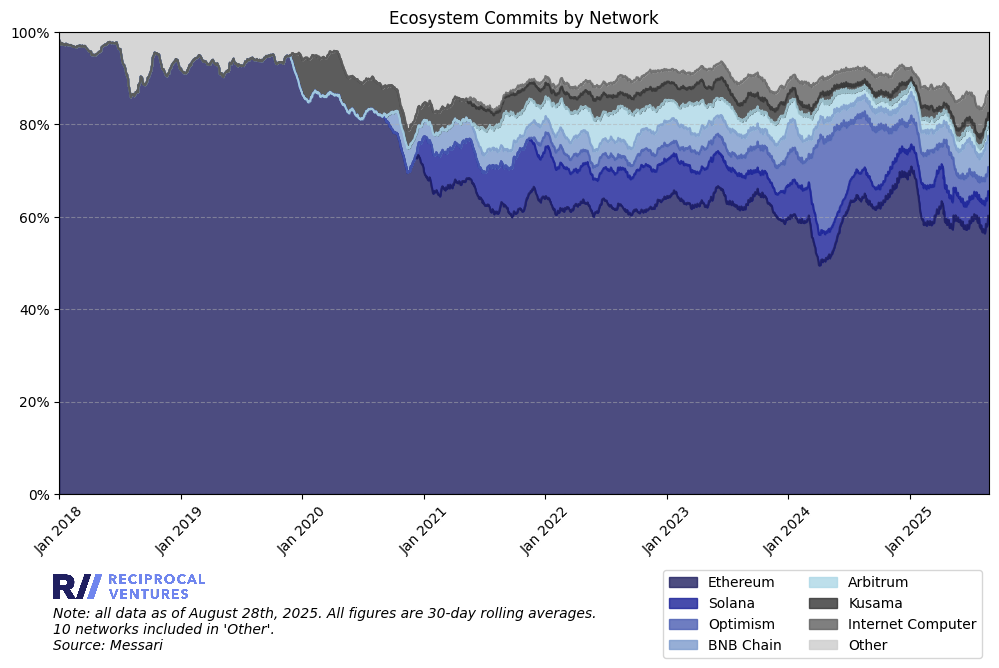

            Ethereum    Solana  Optimism  BNB Chain  Arbitrum    Kusama  \
date                                                                      
2025-08-23  0.593268  0.053954  0.051450   0.069268  0.030310  0.020219   
2025-08-24  0.602529  0.053244  0.052283   0.067406  0.029804  0.019928   
2025-08-25  0.599050  0.053762  0.050040   0.068694  0.030105  0.019857   
2025-08-26  0.595594  0.052763  0.049480   0.070034  0.030974  0.018502   
2025-08-27  0.598394  0.050164  0.049278   0.069745  0.031237  0.018294   

            Internet Computer     Other  
date                                     
2025-08-23           0.050420  0.131111  
2025-08-24           0.047068  0.127737  
2025-08-25           0.048696  0.129796  
2025-08-26           0.050841  0.131810  
2025-08-27           0.051434  0.131454  


In [95]:
metric = ['ecosystemCommits24Hour', 'Ecosystem Commits']
networks = extract_dict
start_date = '2018-01-01'
rolling = 30
n_assets = 7
n_col = 2

ecosystem_metric_by_network(metric, networks, start_date, rolling, n_assets, n_col)